In [16]:
import numpy as np
import matplotlib.pyplot as plt


# EMRI Fisher Analysis

# GENERAL RESULTS FOR EMRI CASE:

EMRI PARARMS: theta0: [1000000.0, 10.0, 0.9, 7.5, 0.5, 0.7853981633974483, 1.0, 0.9, 0.4]
SNR : 

## 1 PA best fit points : 

	final_overlap: 183.28826185751265 (at cv based point overlap is  183.28723154643657)
	x: [999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827]


## 0 PA best fit (BF) points 
	
	Overlap of the best point: 183.28595232649386
	Best point : [1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]

	
## Simple Deviation Term 

	final overlap: 183.28665820258854
	x_best_fit = [1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933]

## PN Informed BF points

	final_overlap: 183.28667312758748
	
	x:  [1000116.7725909345, 10.0007380123631, 0.9000820655953746, 7.4995231787298975, 0.49998442139564336, 0.783936783027285, 1.0111915544579975, 1.0769719349836555, 0.38421222178985337, 7.930069970252246e-07, 6.124962528264624e-07]


In [17]:
def fishinv(M, Fisher, index_of_M=0):
    J = np.eye(len(Fisher))
    J[index_of_M, index_of_M] = M

    Fisher_lnM = J.T @ Fisher @ J
    print('Condition number of Fisher_lnM: ', np.linalg.cond(Fisher_lnM))
    Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)  # Jacobian for Covariance = partial new/partial old, going from lnM -> M
    Fisher_inv = J.T @ Fisher_lnM_inv @ J
    return Fisher_inv

def fishinv_for_dev(M, Fisher, index_of_M=0, scale_factor_1=1, scale_factor_2=1,index_of_dev_1=9, index_of_dev_2=10):
    J = np.eye(len(Fisher))
    J[index_of_M, index_of_M] = M
    J[index_of_dev_1, index_of_dev_1] = scale_factor_1
    J[index_of_dev_2, index_of_dev_2] = scale_factor_2

    Fisher_lnM = J.T @ Fisher @ J
    print('Condition number of Fisher_lnM: ', np.linalg.cond(Fisher_lnM))
    Fisher_lnM_inv = np.linalg.inv(Fisher_lnM)  # Jacobian for Covariance = partial new/partial old, going from lnM -> M
    Fisher_inv = J.T @ Fisher_lnM_inv @ J
    return Fisher_inv

In [21]:
ls

1gen_results/  Result/  output.png      src/
README.md      main.py  pyproject.toml  uv.lock


In [22]:
# Loaaind the FIsher and checking condition number
Fisher_0PA = np.load('1gen_results/Fisher_0PA_emri.npy')
Fisher_1PA = np.load('1gen_results/Fisher_1PA_emri.npy')
Fisher_0PA_dev_simple = np.load('1gen_results/Fisher_0PA_dev_simple_emri.npy')
Fisher_0PA_dev_PN_informed = np.load('1gen_results/Fisher_0PA_dev_PN_informed_emri.npy')
Fisher_1PA_dev = np.load('1gen_results/Fisher_1PA_dev.npy')

print('Condition number of 0PA Fisher: ', np.linalg.cond(Fisher_0PA))
print('Condition number of 1PA Fisher: ', np.linalg.cond(Fisher_1PA))
print('Condition number of 0PA dev simple Fisher: ', np.linalg.cond(Fisher_0PA_dev_simple))
print('Condition number of 0PA dev PN informed Fisher: ', np.linalg.cond(Fisher_0PA_dev_PN_informed))
print('Condition number of 1PA dev Fisher: ', np.linalg.cond(Fisher_1PA_dev))


Condition number of 0PA Fisher:  1.2286336507477106e+21
Condition number of 1PA Fisher:  1.033097974407764e+21
Condition number of 0PA dev simple Fisher:  1.6068288142351547e+24
Condition number of 0PA dev PN informed Fisher:  1.5732248856179995e+21
Condition number of 1PA dev Fisher:  1.7606618707026628e+21


In [23]:
## 1 PA best fit points : 

bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_simple_dev = np.array([1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933])  
bf_PN_informed_dev = np.array([1000116.7725909345, 10.0007380123631, 0.9000820655953746, 7.4995231787298975, 0.49998442139564336, 0.783936783027285, 1.0111915544579975, 1.0769719349836555, 0.38421222178985337, 7.930069970252246e-07, 6.124962528264624e-07])
bf_1_PA_dev= np.array([1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868])

In [24]:
Covariance_fit_1PA = fishinv(bf_1PA[0], Fisher_0PA, index_of_M=0)
Covariance_fit_0PA = fishinv(bf_0PA[0], Fisher_1PA, index_of_M=0)


Condition number of Fisher_lnM:  2140425901649340.5
Condition number of Fisher_lnM:  2343261743847449.5


In [25]:
Covariance_fit_0PA_dev_simple = fishinv_for_dev(bf_simple_dev[0], Fisher_0PA_dev_simple, index_of_M=0, scale_factor_1=1e6, scale_factor_2=1e6, index_of_dev_1=9, index_of_dev_2=10)
Covariance_fit_0PA_dev_PN_informed = fishinv_for_dev(bf_PN_informed_dev[0], Fisher_0PA_dev_PN_informed,
                                                      index_of_M=0, scale_factor_1=1, scale_factor_2=1, index_of_dev_1=9, index_of_dev_2=10)


Condition number of Fisher_lnM:  8754257972607508.0
Condition number of Fisher_lnM:  2374007230897129.0


In [26]:
Covariance_1PA_dev = fishinv_for_dev(bf_1_PA_dev[0], Fisher_1PA_dev, index_of_M=0, scale_factor_1=1e6, scale_factor_2=1e6, index_of_dev_1=9, index_of_dev_2=10)

Condition number of Fisher_lnM:  6425937863076332.0


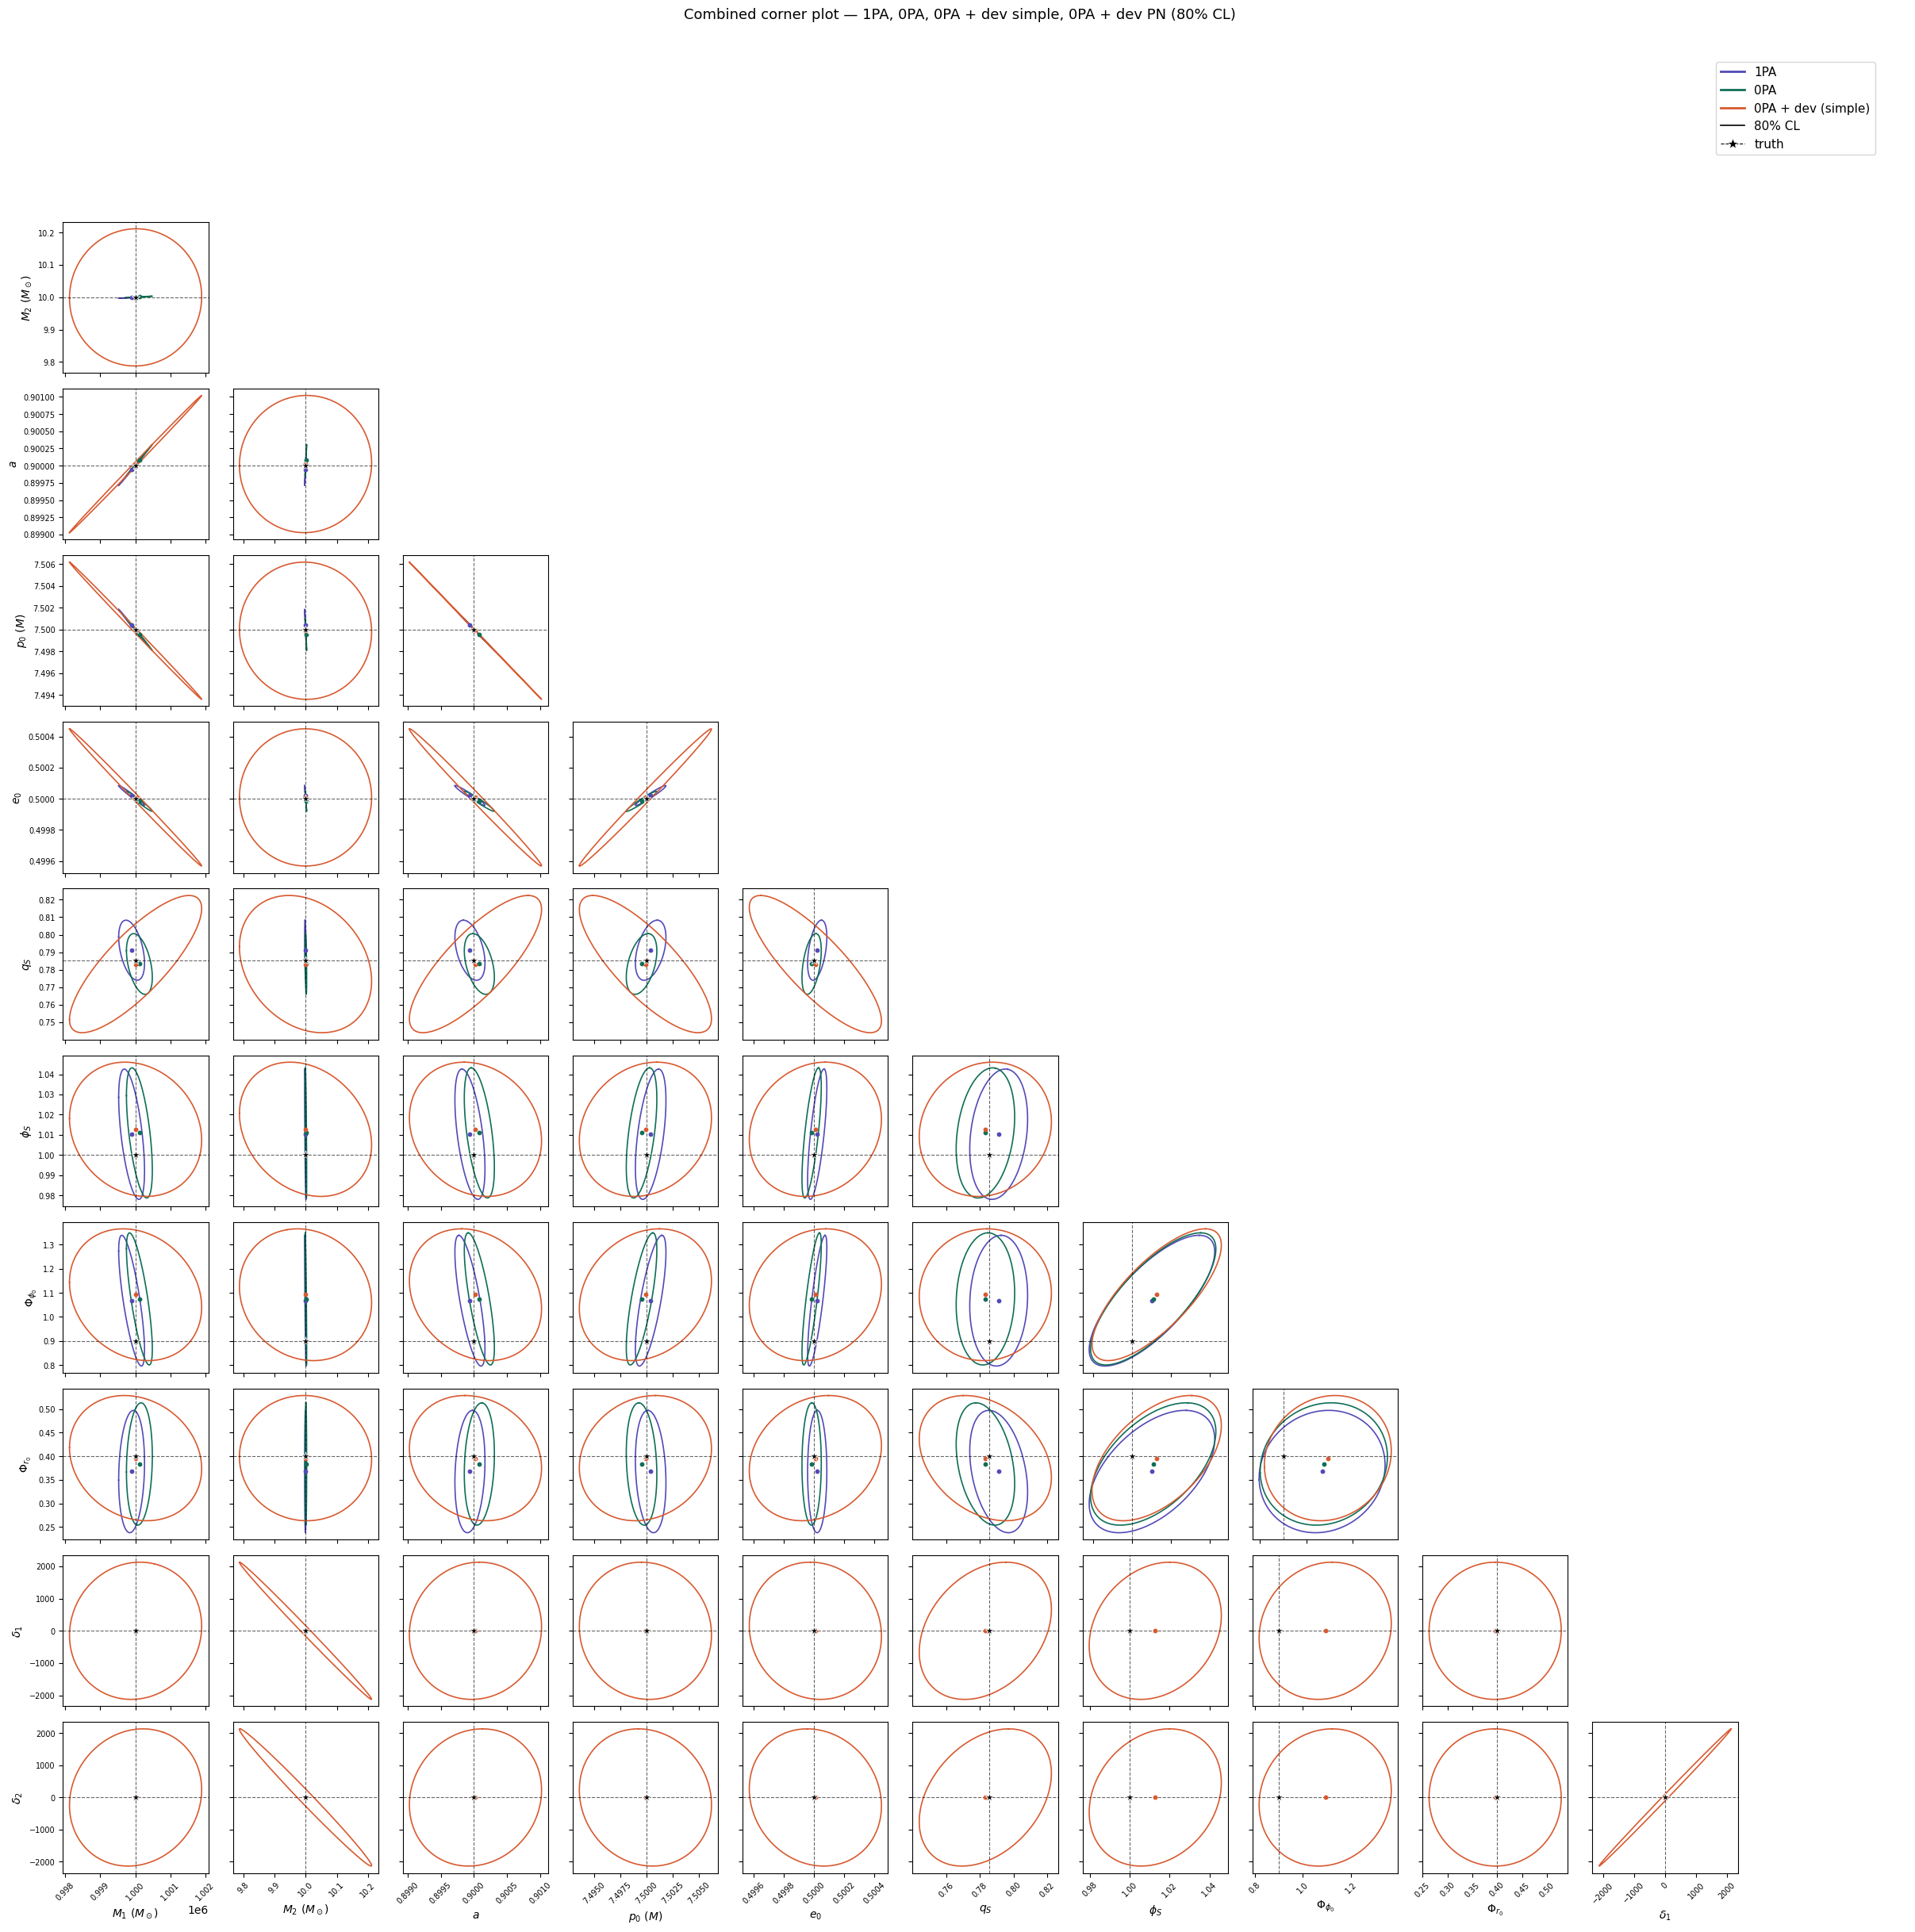

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_simple_dev = np.array([1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933])  

# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('0PA + dev (simple)', bf_simple_dev,     Covariance_fit_0PA_dev_simple, '#D85A30', 11),

]
level= 0.8
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


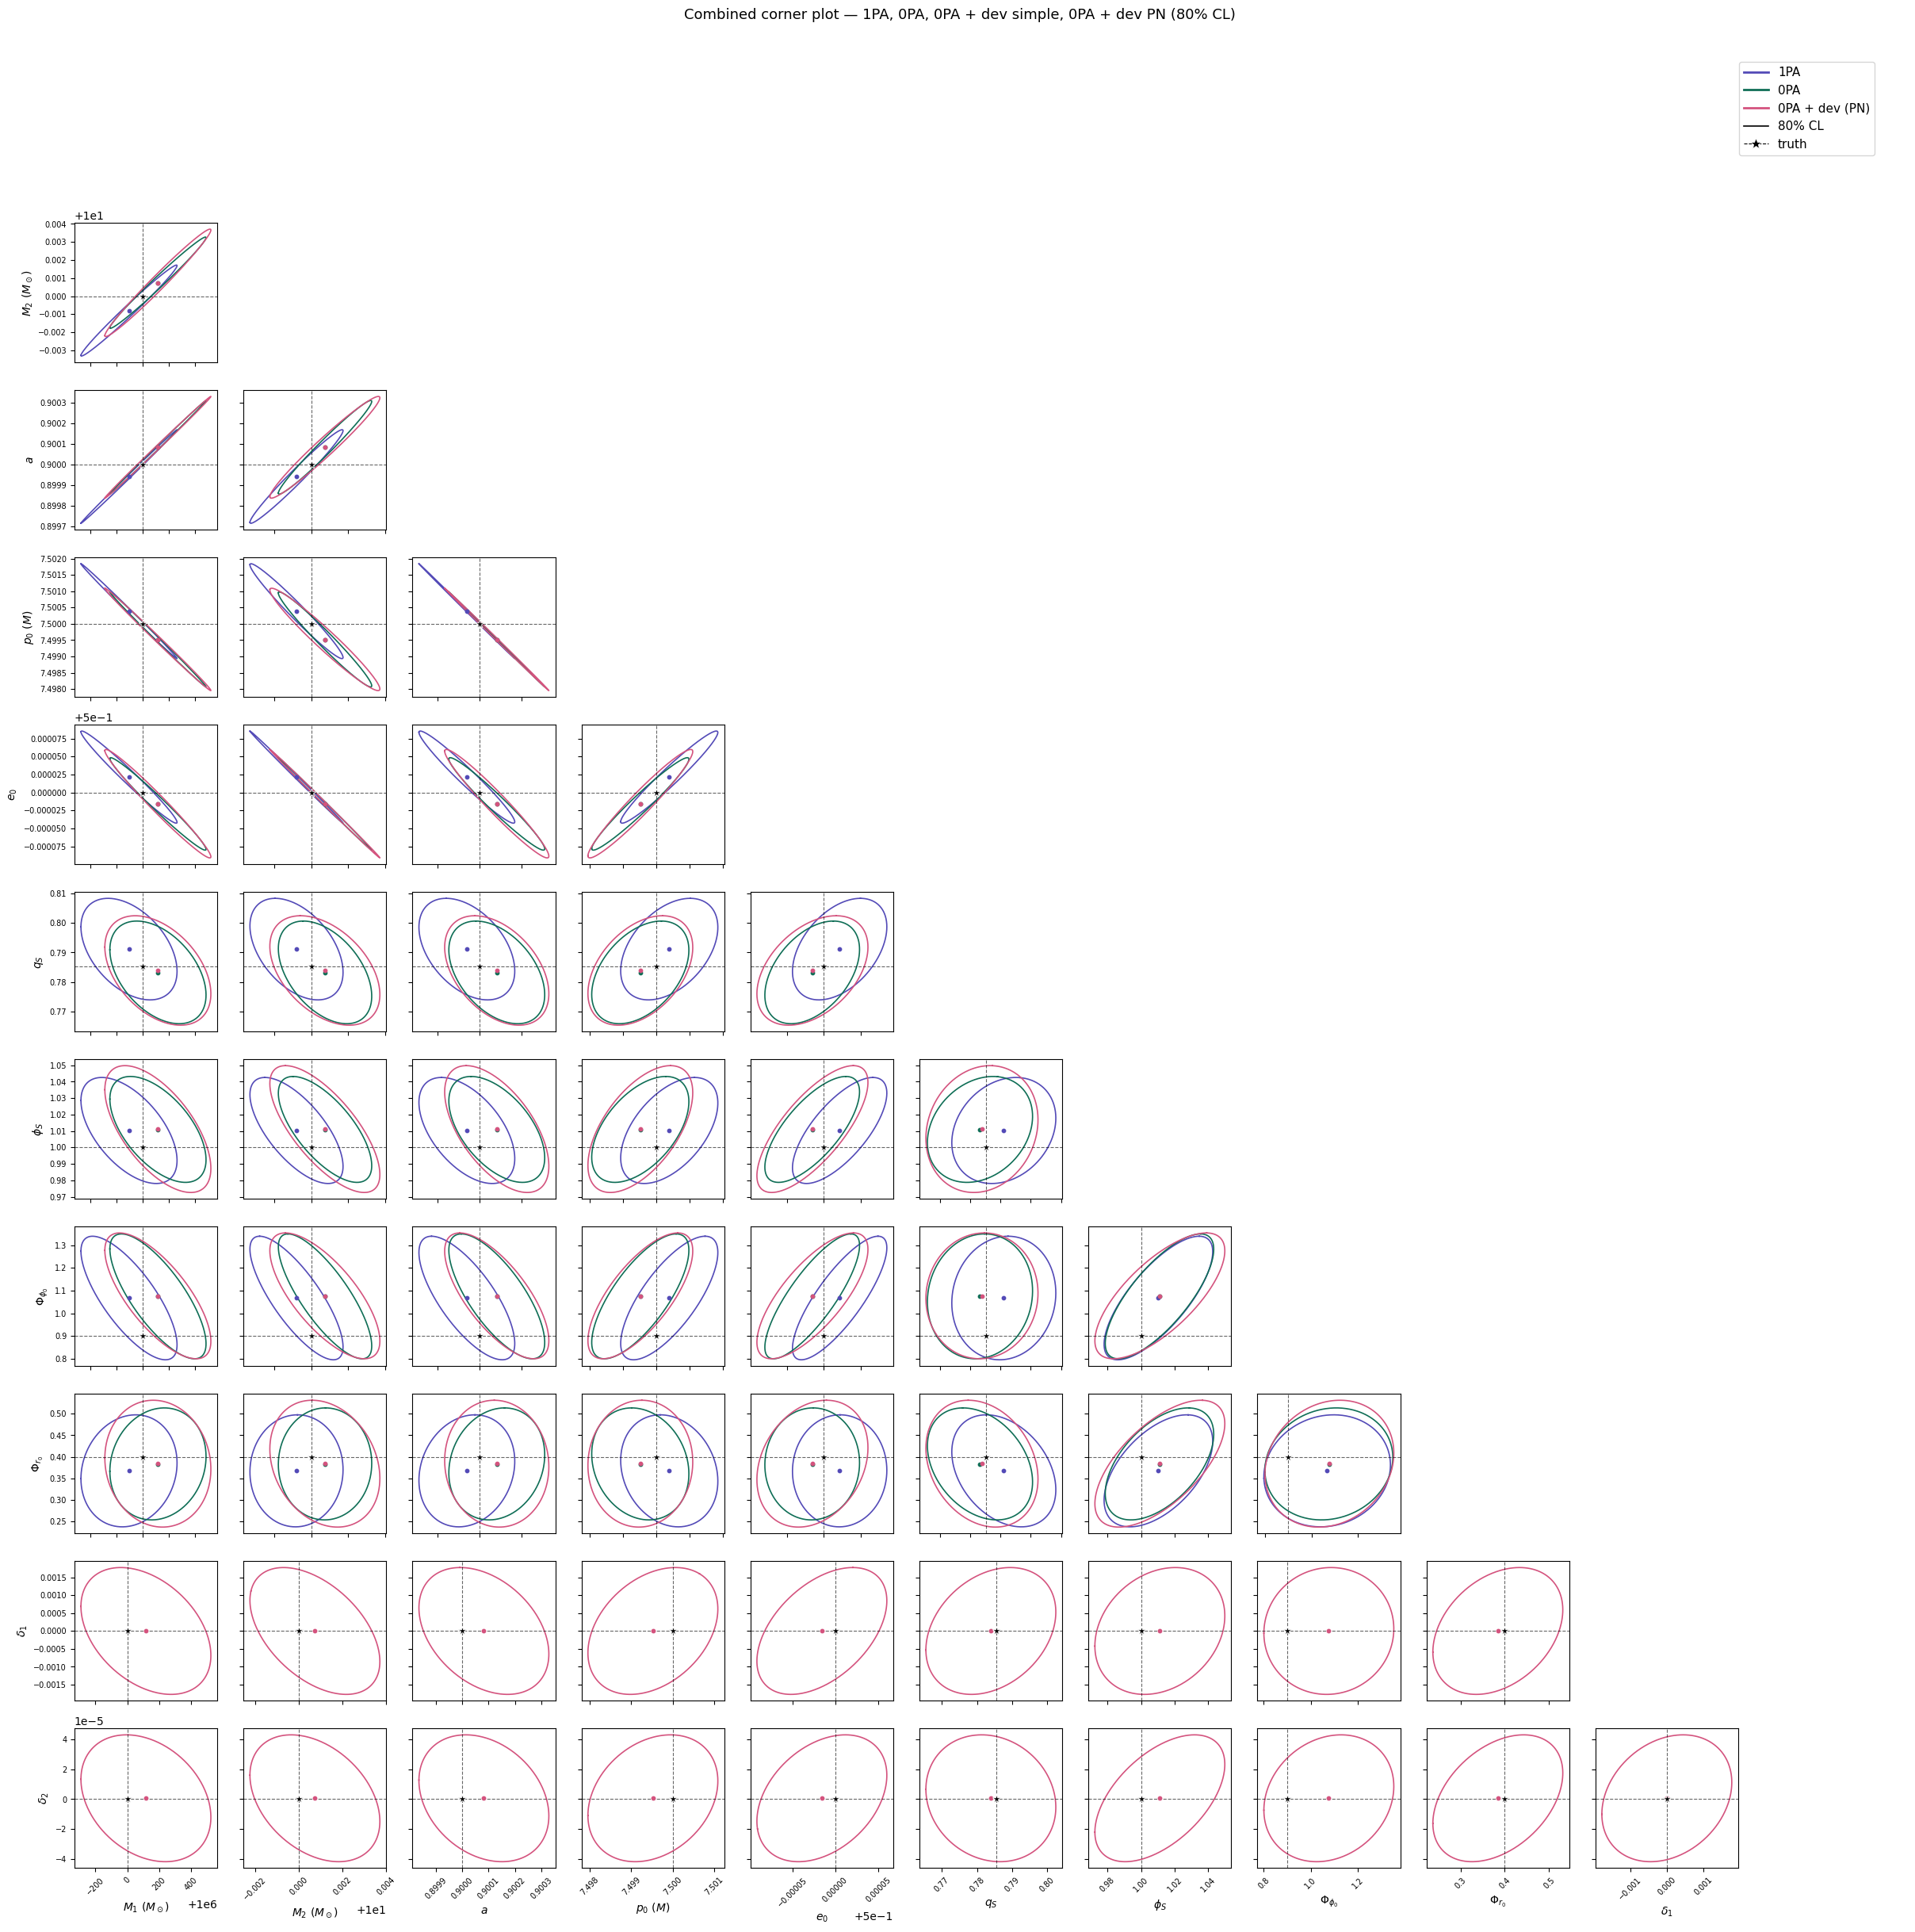

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_1_PA_dev= np.array([1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868])


# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('0PA + dev (PN)',     bf_PN_informed_dev, Covariance_fit_0PA_dev_PN_informed,     '#D4537E', 11),
]
level= 0.8
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


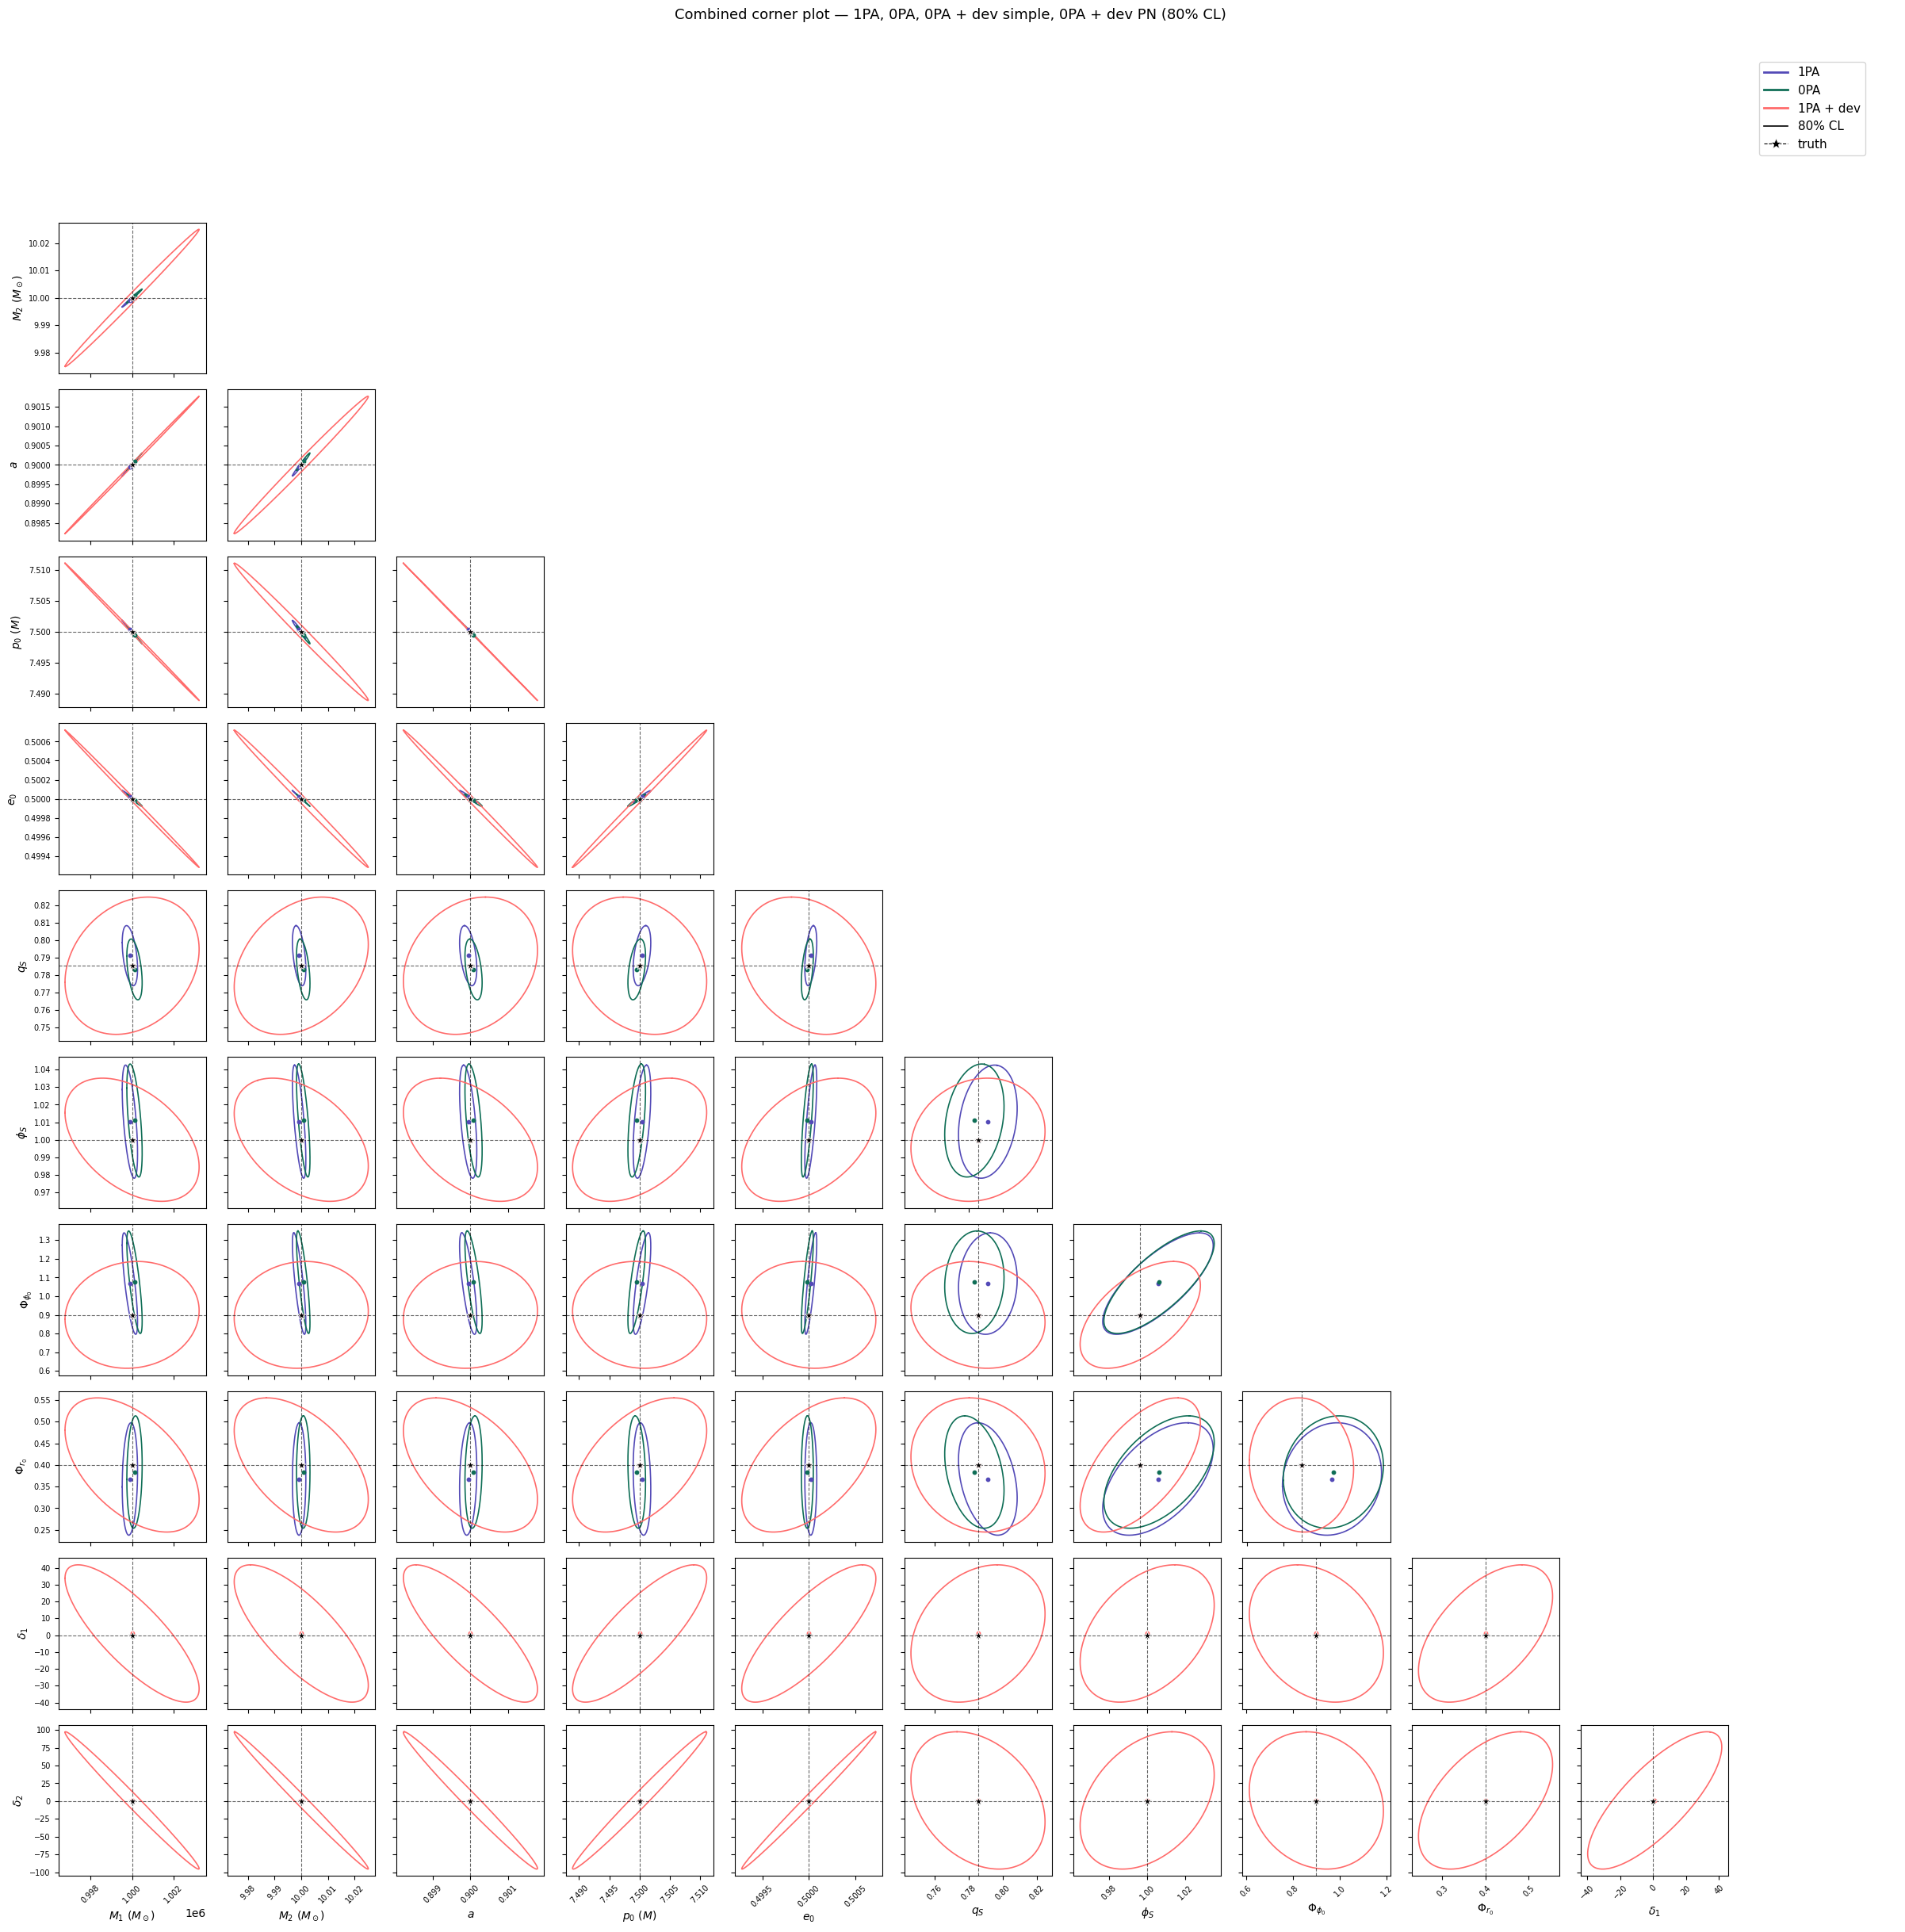

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_1_PA_dev= np.array([1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868])


# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('1PA + dev',          bf_1_PA_dev,       Covariance_1PA_dev,            '#FF6B6B', 11),
]

level= 0.8
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


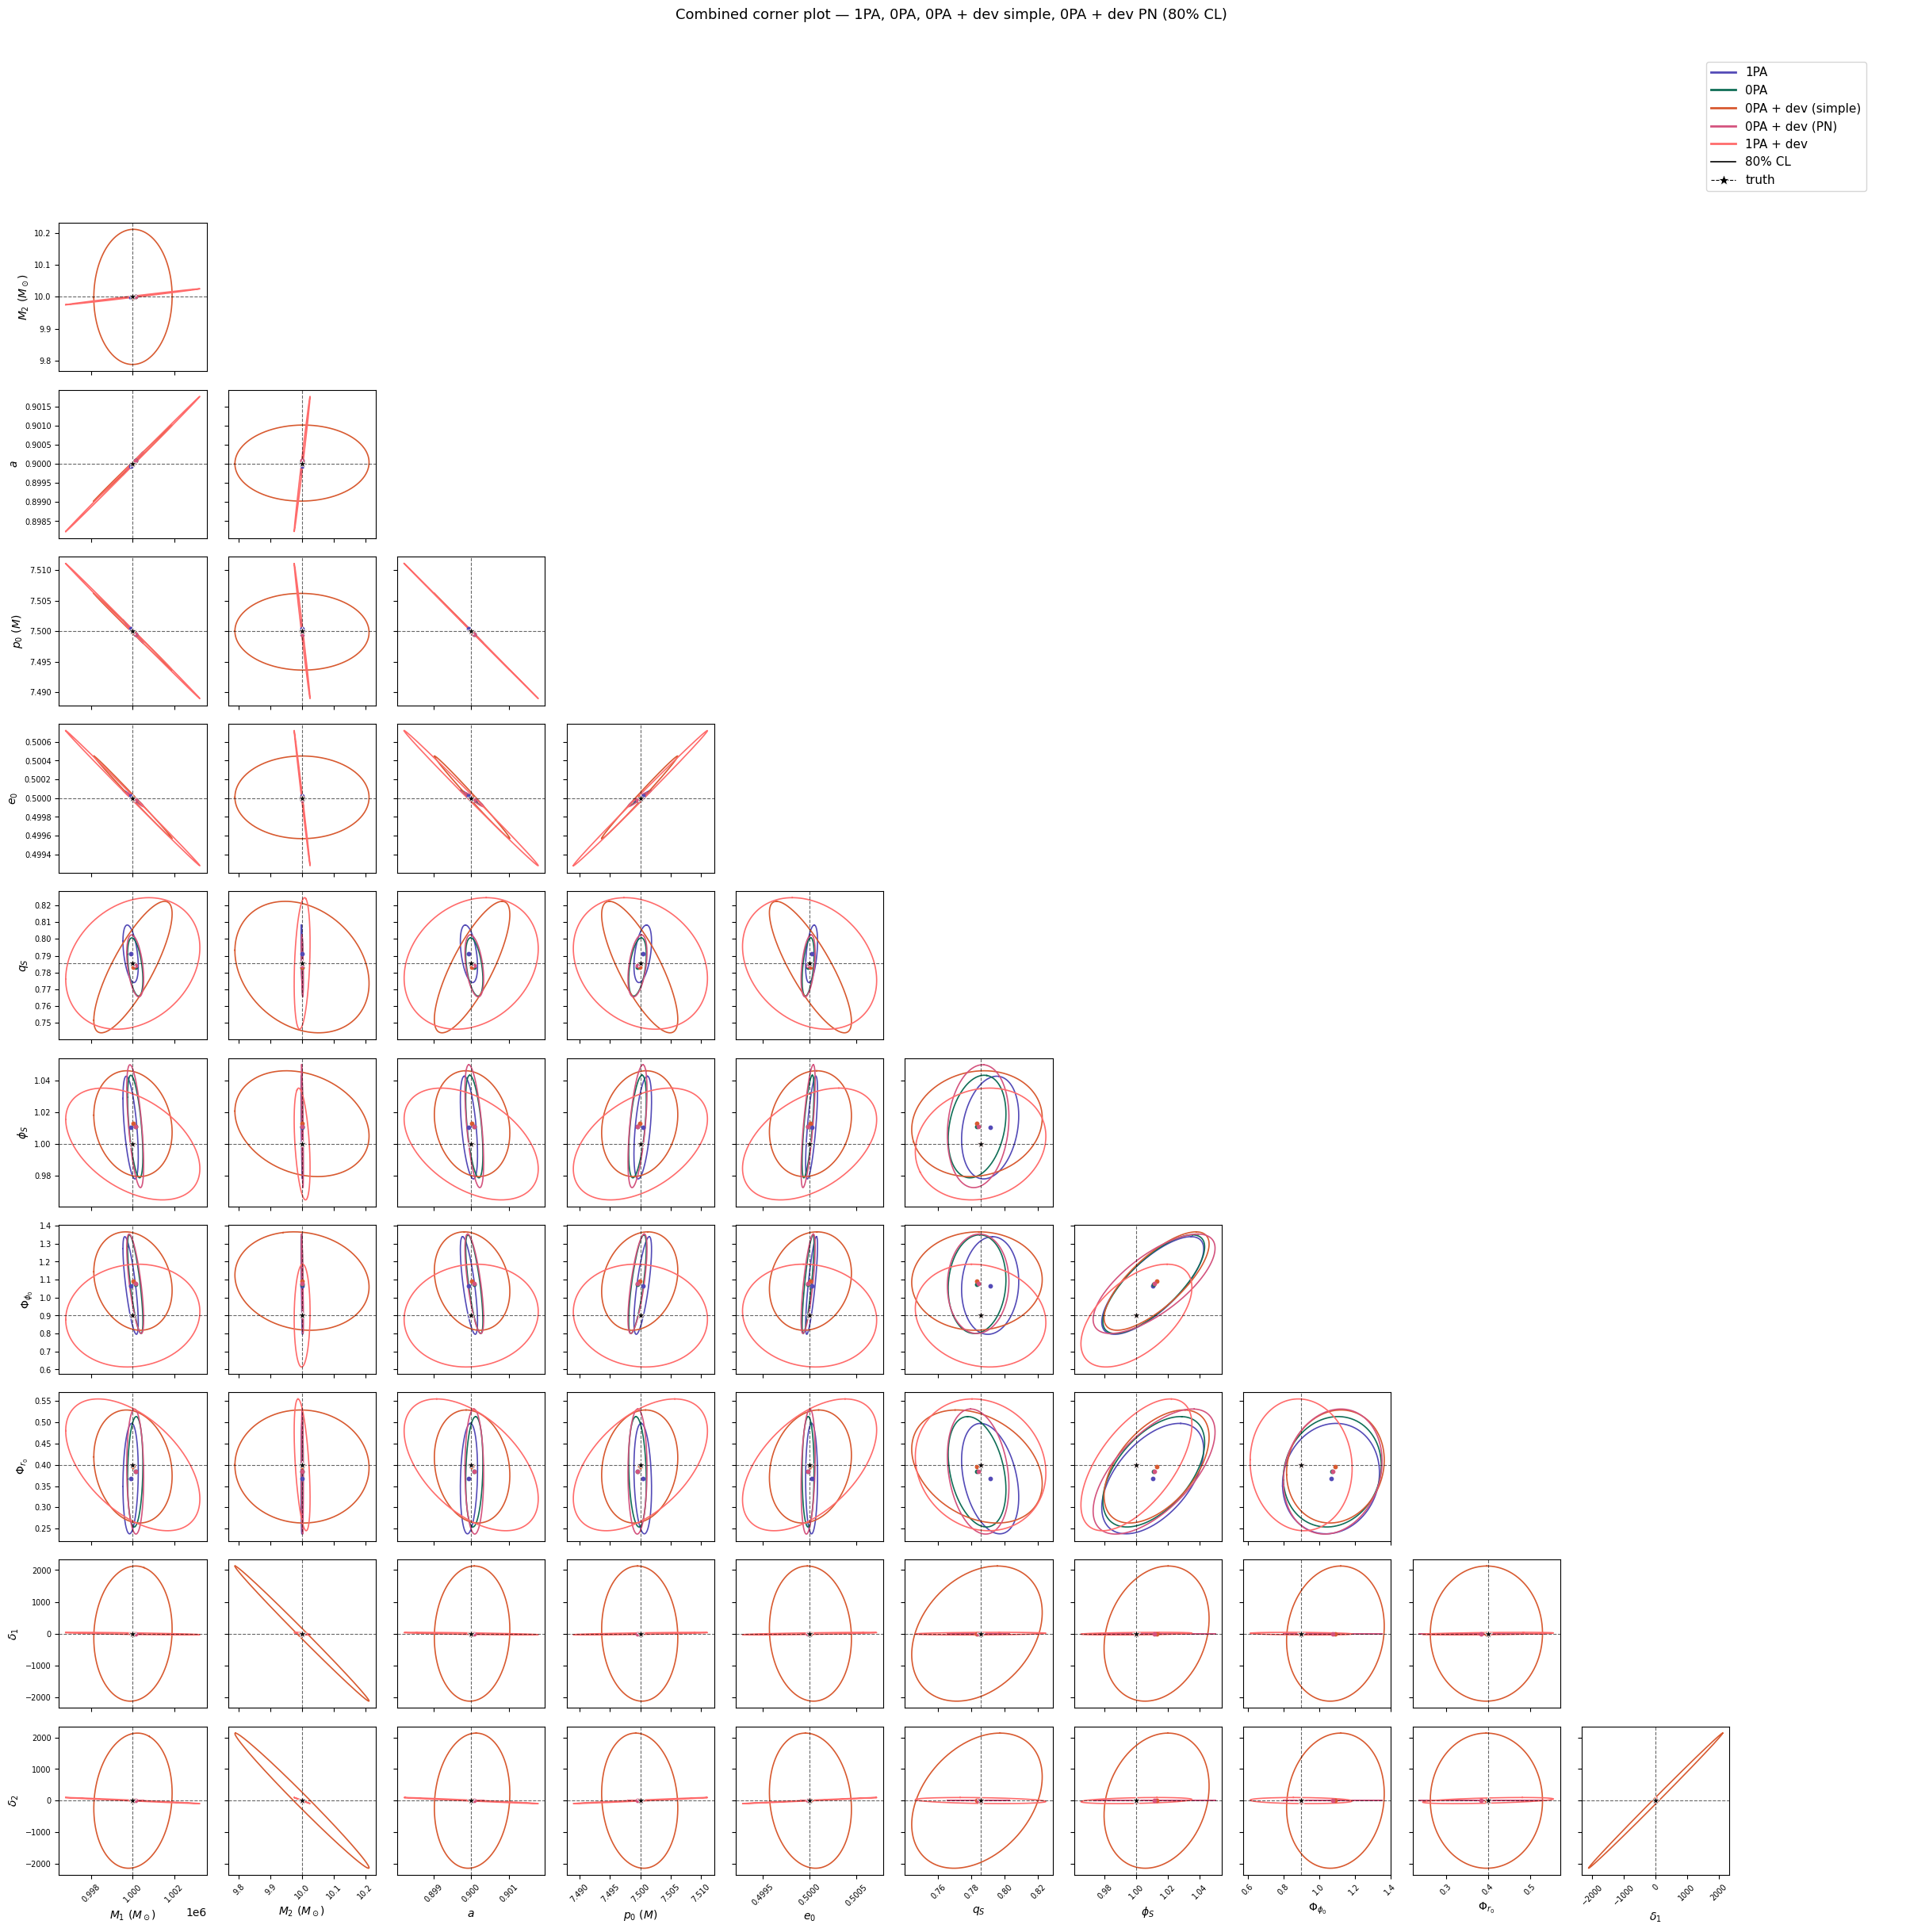

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_simple_dev = np.array([1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933])  
bf_PN_informed_dev = np.array([1000116.7725909345, 10.0007380123631, 0.9000820655953746, 7.4995231787298975, 0.49998442139564336, 0.783936783027285, 1.0111915544579975, 1.0769719349836555, 0.38421222178985337, 7.930069970252246e-07, 6.124962528264624e-07])
bf_1_PA_dev= np.array([1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868])
# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('0PA + dev (simple)', bf_simple_dev,     Covariance_fit_0PA_dev_simple, '#D85A30', 11),
    ('0PA + dev (PN)',     bf_PN_informed_dev, Covariance_fit_0PA_dev_PN_informed,     '#D4537E', 11),
    ('1PA + dev',          bf_1_PA_dev,       Covariance_1PA_dev,            '#FF6B6B', 11),
]
level= 0.8
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='80% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle(f'Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({level*100:.0f}% CL)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


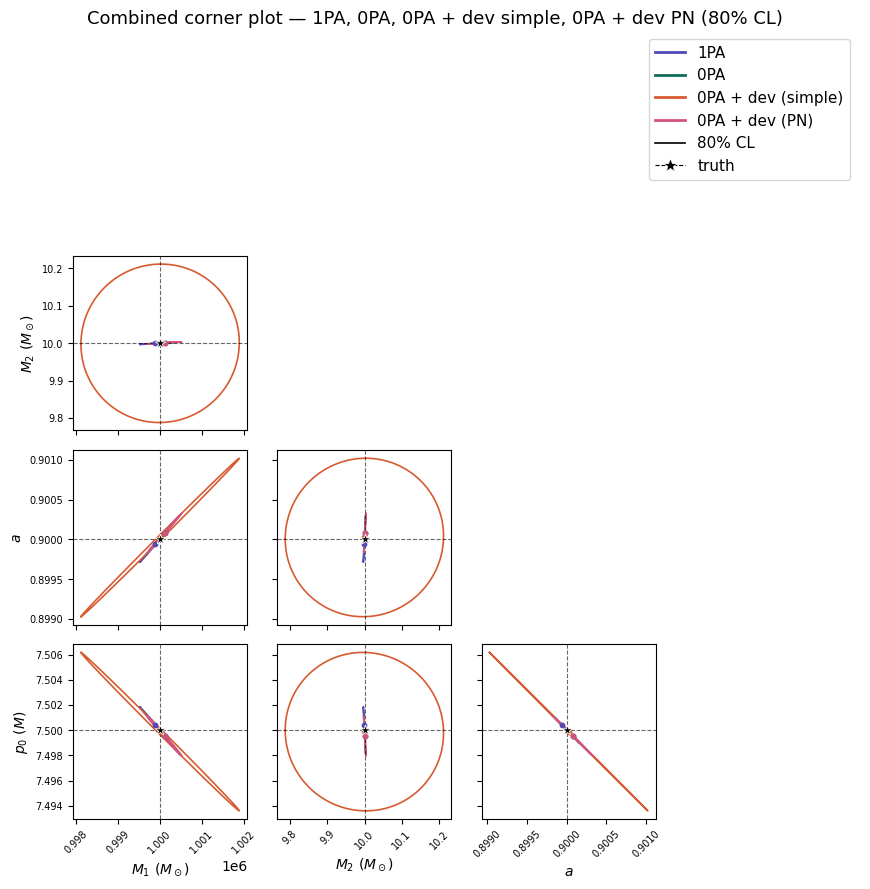

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([999894.8642202921, 9.99920420648945, 0.8999403453809112, 7.500388327250165, 0.5000214239573864, 0.7911480317189448, 1.0103259434845695, 1.0674573624561179, 0.3675966046004827])
bf_0PA = np.array([1000117.4489066871, 10.000747713536276, 0.9000821275834304, 7.499521999767378, 0.49998410573186125, 0.7832871364017695, 1.010973741062668, 1.0747886916109437, 0.38364873884565026]) 
bf_simple_dev = np.array([1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933])  
bf_PN_informed_dev = np.array([1000116.7725909345, 10.0007380123631, 0.9000820655953746, 7.4995231787298975, 0.49998442139564336, 0.783936783027285, 1.0111915544579975, 1.0769719349836555, 0.38421222178985337, 7.930069970252246e-07, 6.124962528264624e-07])
bf_1_PA_dev= np.array([1000000.0, 10.000000009924808, 0.8999997959803092, 7.499999983316402, 0.5000000389251131, 0.7853981634909842, 0.9999999999362225, 0.9000000000576618, 0.3999999999899322, 1.0000000307877215, 0.9999998929309868])
# True injected parameters — order MUST match `labels` below.
signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
Nshow = 4  # how many fits to show (in order of `fits` list)

fits = [
    ('1PA',                bf_1PA[:Nshow],            Covariance_fit_1PA[:Nshow, :Nshow],            '#534AB7', 9),
    ('0PA',                bf_0PA[:Nshow],            Covariance_fit_0PA[:Nshow, :Nshow],            '#0F6E56', 9),
    ('0PA + dev (simple)', bf_simple_dev[:Nshow],     Covariance_fit_0PA_dev_simple[:Nshow, :Nshow], '#D85A30', 11),
    ('0PA + dev (PN)',     bf_PN_informed_dev[:Nshow], Covariance_fit_0PA_dev_PN_informed[:Nshow, :Nshow],     '#D4537E', 11),
    ('1PA + dev',          bf_1_PA_dev[:Nshow],       Covariance_1PA_dev[:Nshow, :Nshow],            "#E3FF2A", 11),
]
level= 0.8
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = Nshow
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits[:Nshow]:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits[:Nshow]]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='80% CL'))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle(f'Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({level*100:.0f}% CL)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


# GENERAL RESULTS FOR IMRI CASE:

IMRI params : [1000000.0, 5000.0, 0.7, 25.0, 0.25, 0.7853981633974483, 1.0, 0.9, 0.4, 0.0, 0.0]
SNR: 

## 1 PA best fit points: 
	
	final_overlap_1stgen: 383.0741792097147
	
	x: [1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434]

RUNNING
## 0 PA best fit (BF) points: 

	final_overlap: 383.051286770164
	
	theta0: [1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]


## Simple Deviation Term

	final_overlap: 383.06223065777056
	x_bf = [1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, 0.7875895689149237, 1.001918539952816, 0.9156601963955119, 0.4109580708321073, 1.7364060670631016, 2.1384810088591153]



## PN informed BF points
	
	final_overlap : 383.06587515586455
	[1001746.8662793704, 4981.874856346291, 0.7042095448190115, 24.96226811525148, 0.2502467124648788, 0.7877840055125346, 1.0019808615795052, 0.9019863610862191, 0.41409936930468483, -2.5508432126243203, -0.0019346983684825976]

In [33]:
pwd

'/home/svu/e1583490/bias_inference_emri'

In [34]:
# Loaaind the FIsher and checking condition number
Fisher_0PA = np.load('1gen_results/Fisher_0PA_imri.npy')
Fisher_1PA = np.load('1gen_results/Fisher_1PA_imri.npy')
Fisher_0PA_dev_simple = np.load('1gen_results/Fisher_0PA_dev_simple_imri.npy')
Fisher_0PA_dev_PN_informed = np.load('1gen_results/Fisher_0PA_dev_PN_informed_imri.npy')
Fisher_1PA_dev = np.load('1gen_results/Fisher_1PA_dev_imri.npy')
print('Condition number of 0PA Fisher: ', np.linalg.cond(Fisher_0PA))
print('Condition number of 1PA Fisher: ', np.linalg.cond(Fisher_1PA))
print('Condition number of 0PA dev simple Fisher: ', np.linalg.cond(Fisher_0PA_dev_simple))
print('Condition number of 0PA dev PN informed Fisher: ', np.linalg.cond(Fisher_0PA_dev_PN_informed))
print('Condition number of 1PA dev Fisher: ', np.linalg.cond(Fisher_1PA_dev))


Condition number of 0PA Fisher:  3.2337679289462415e+18
Condition number of 1PA Fisher:  3.249191120466917e+18
Condition number of 0PA dev simple Fisher:  9.174048840659832e+18
Condition number of 0PA dev PN informed Fisher:  2.2550099600759144e+19
Condition number of 1PA dev Fisher:  8.233940121979707e+18


In [35]:
bf_1PA = np.array([1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434])
bf_0PA = np.array([1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]) 
bf_simple_dev = np.array([1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, 0.7875895689149237, 1.001918539952816, 0.9156601963955119, 0.4109580708321073, 1.7364060670631016, 2.1384810088591153])  
bf_PN_informed_dev = np.array([1001746.8662793704, 4981.874856346291, 0.7042095448190115, 24.96226811525148, 0.2502467124648788, 0.7877840055125346, 1.0019808615795052, 0.9019863610862191, 0.41409936930468483, -2.5508432126243203, -0.0019346983684825976])
bf_1_PA_dev= np.array([1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847])

In [36]:
Covariance_fit_1PA = fishinv(bf_1PA[0], Fisher_0PA, index_of_M=0)
Covariance_fit_0PA = fishinv(bf_0PA[0], Fisher_1PA, index_of_M=0)
Covariance_fit_0PA_dev_simple = fishinv(bf_simple_dev[0], Fisher_0PA_dev_simple, index_of_M=0)
Covariance_fit_0PA_dev_PN_informed = fishinv(bf_PN_informed_dev[0], Fisher_0PA_dev_PN_informed, index_of_M=0)


Condition number of Fisher_lnM:  133361442887311.52
Condition number of Fisher_lnM:  135973550980774.22
Condition number of Fisher_lnM:  8.024409720336842e+16
Condition number of Fisher_lnM:  4.117247833724197e+16


In [37]:
Covariance_1PA_dev = fishinv_for_dev(bf_1_PA_dev[0], Fisher_1PA_dev,
                                                      index_of_M=0, scale_factor_1=1, scale_factor_2=10, index_of_dev_1=9, index_of_dev_2=10)

Condition number of Fisher_lnM:  761149535442649.8


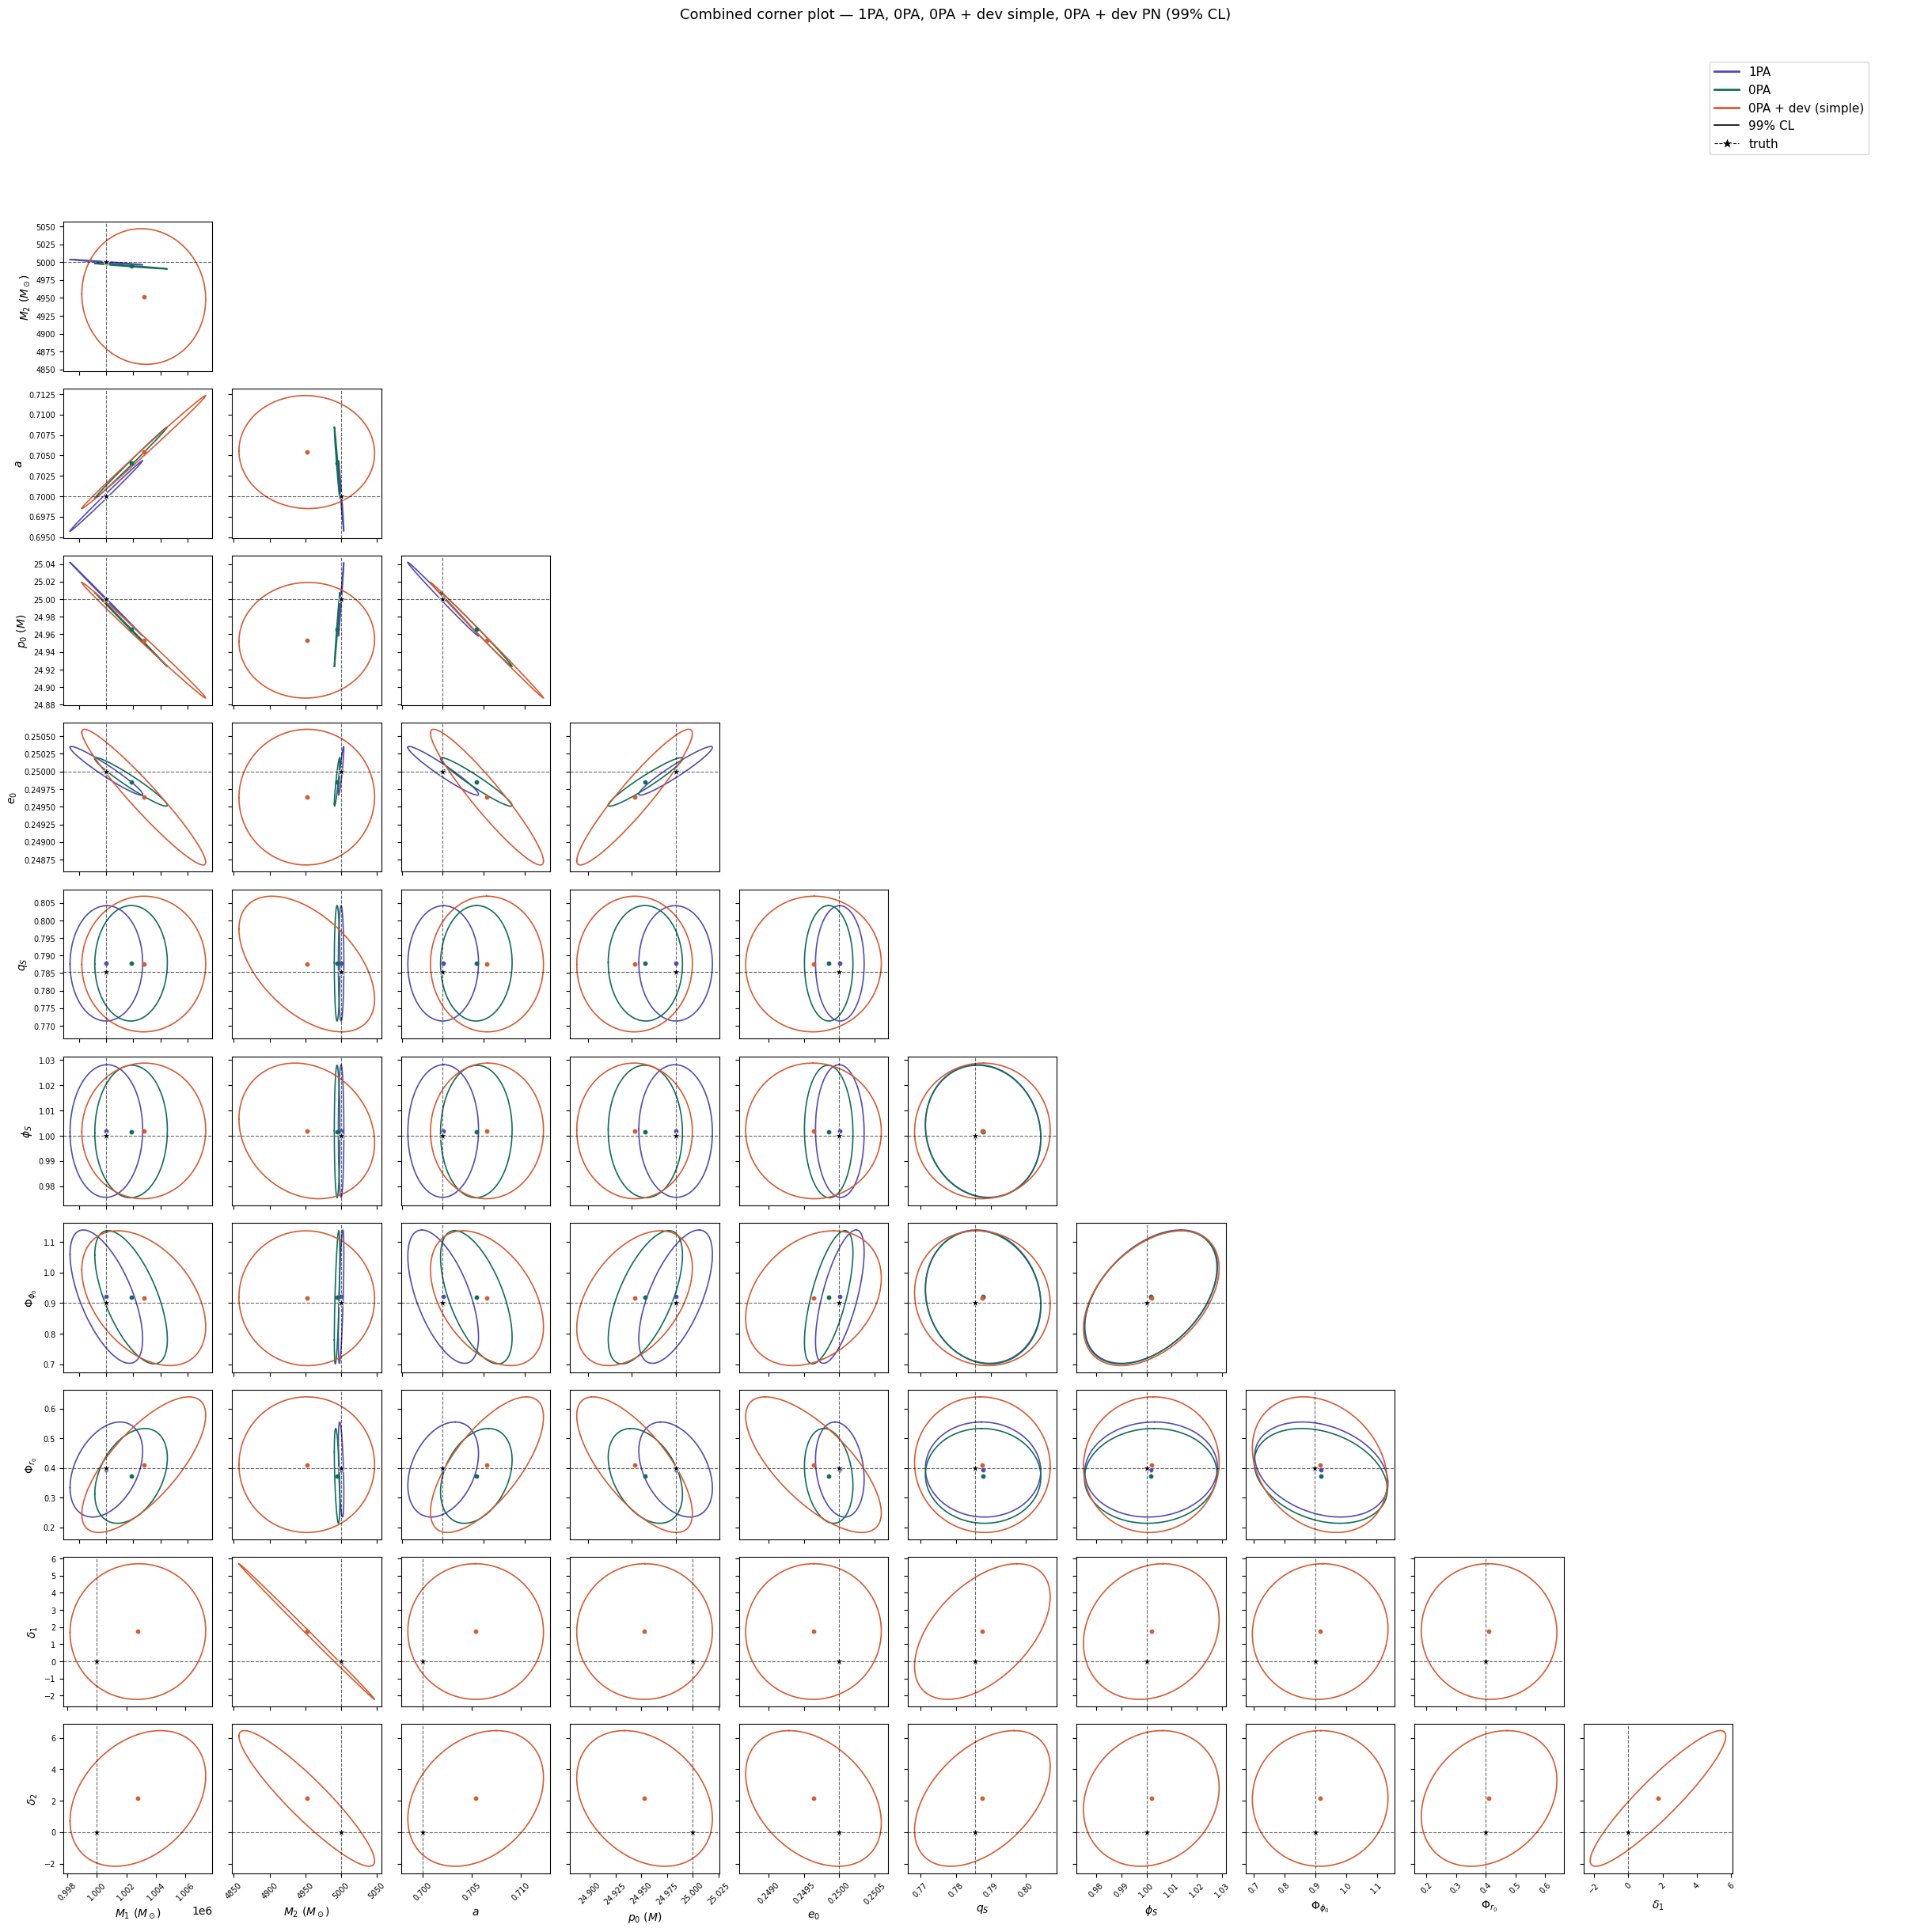

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434])
bf_0PA = np.array([1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]) 
bf_simple_dev = np.array([1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, 0.7875895689149237, 1.001918539952816, 0.9156601963955119, 0.4109580708321073, 1.7364060670631016, 2.1384810088591153])  

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('0PA + dev (simple)', bf_simple_dev,     Covariance_fit_0PA_dev_simple, '#D85A30', 11),

]
level= 0.99
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


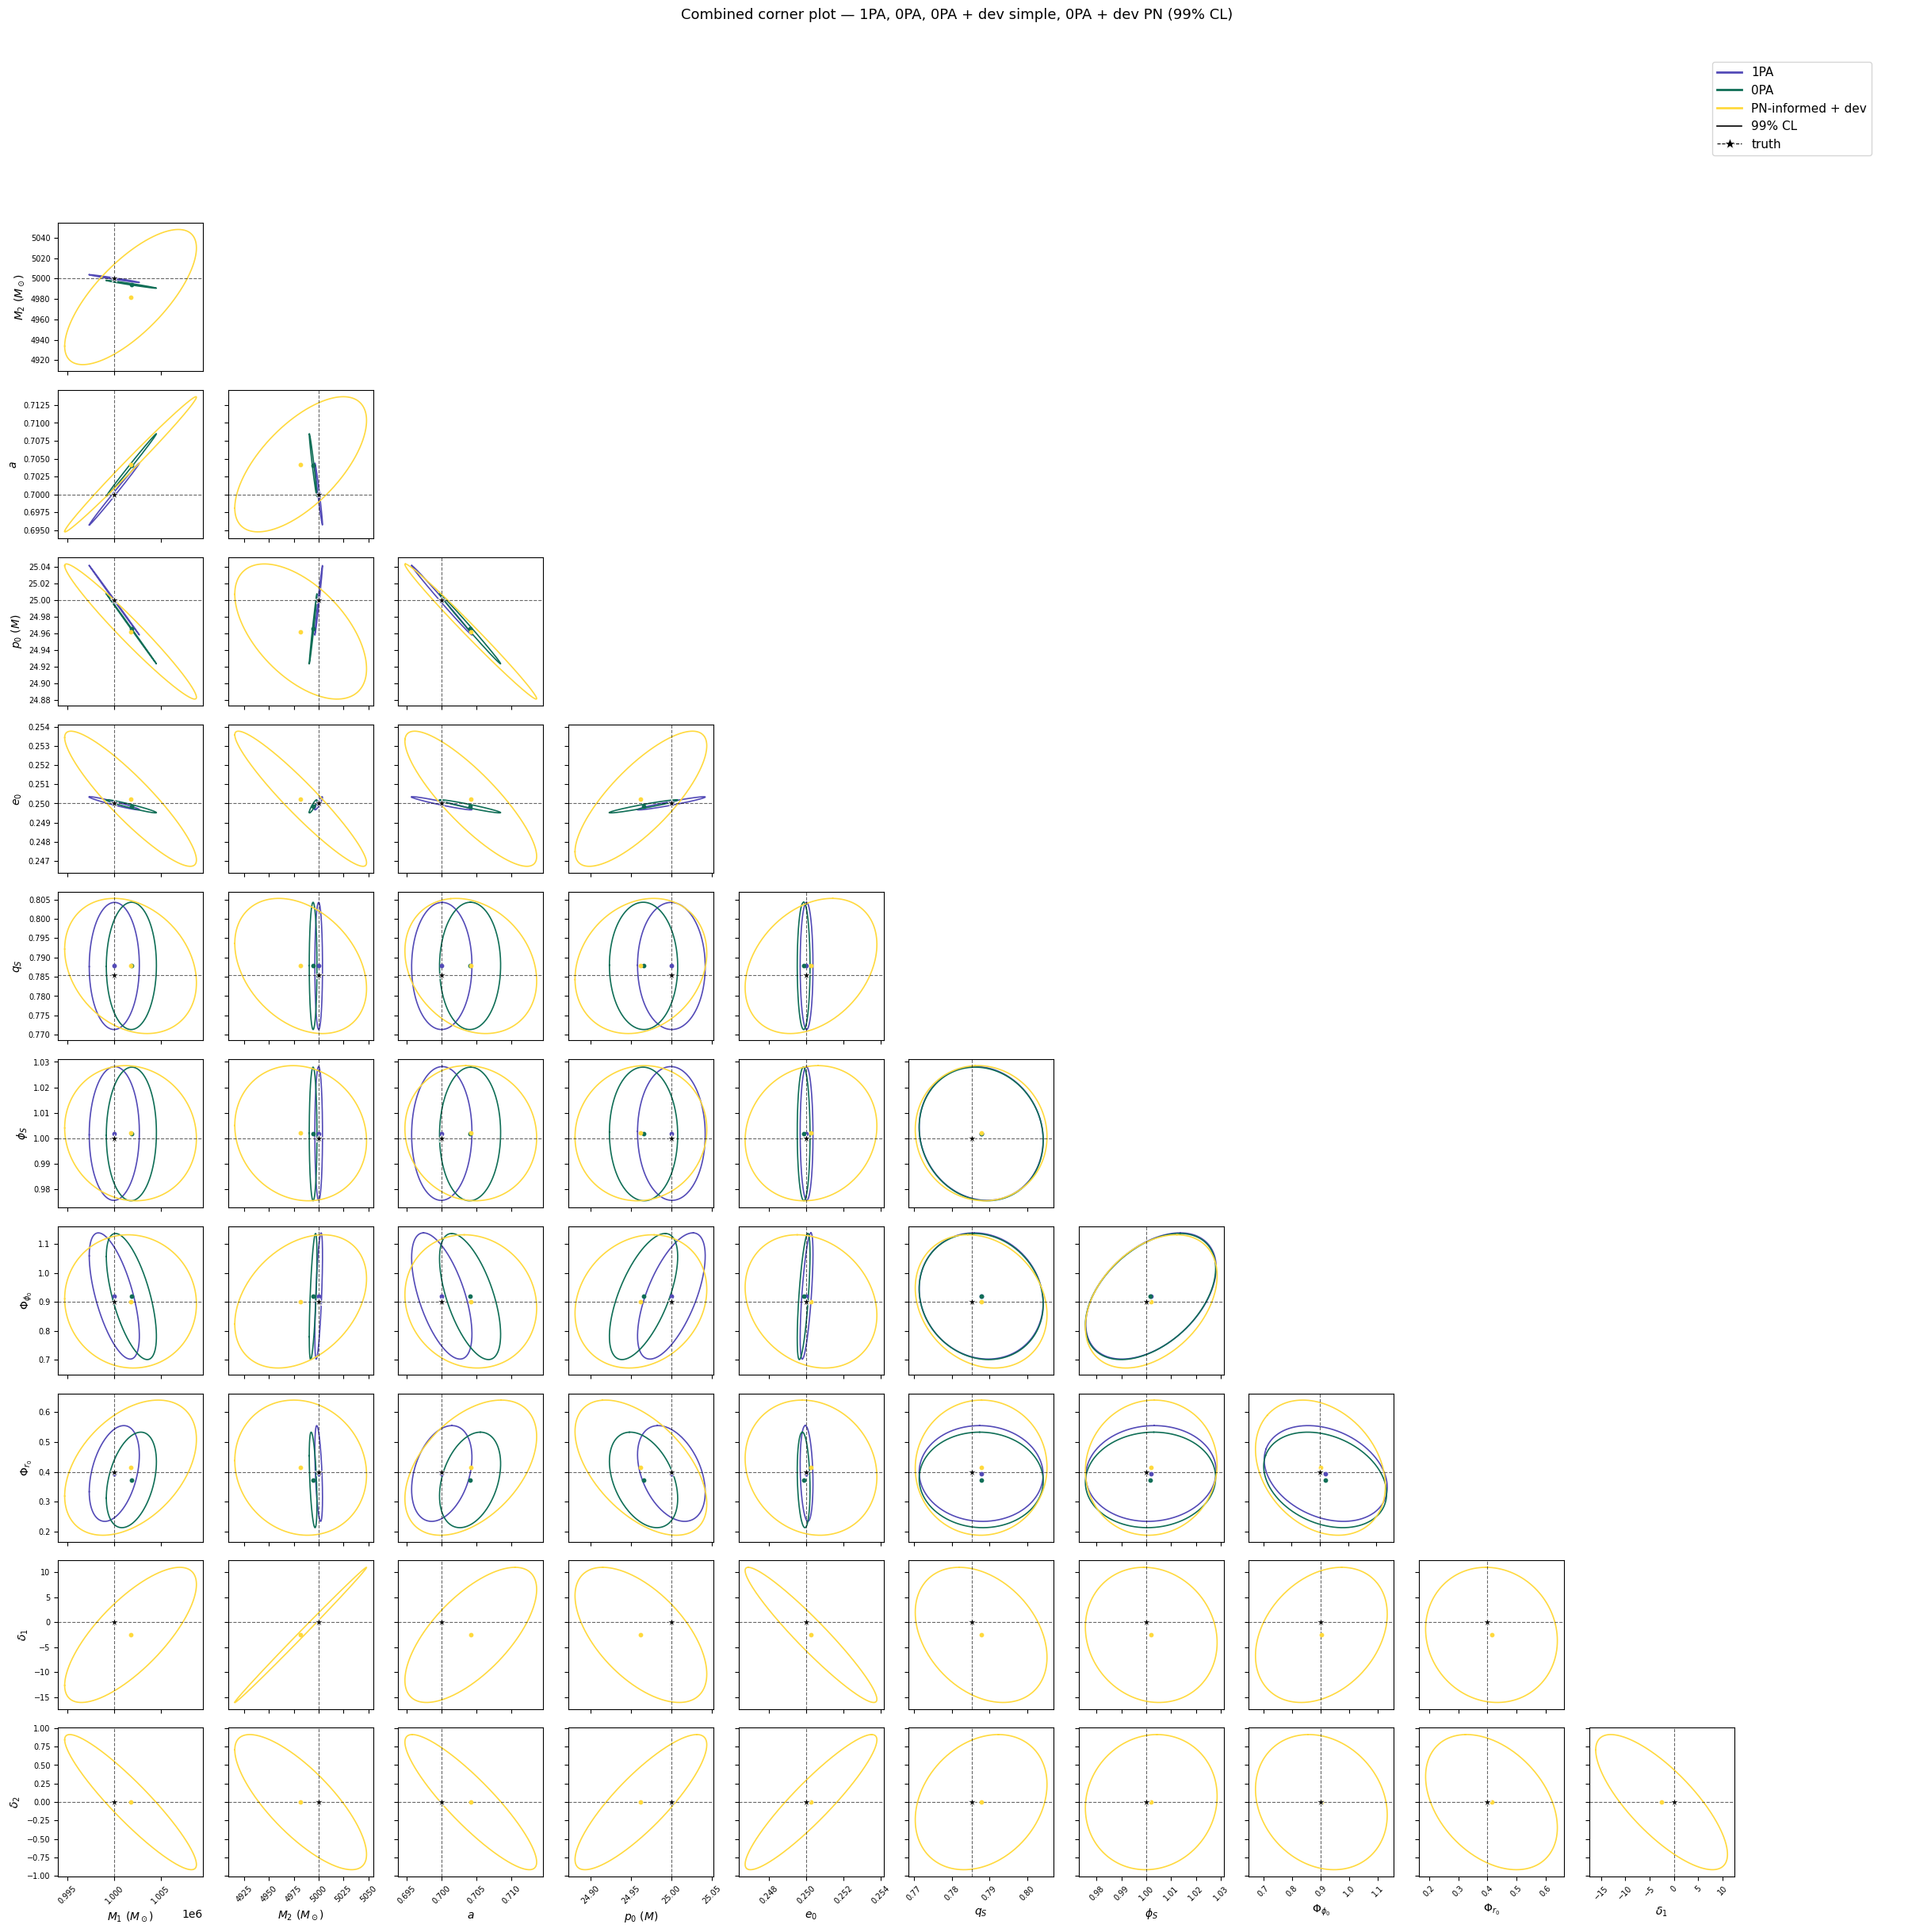

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434])
bf_0PA = np.array([1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]) 
bf_PN_informed_dev = np.array([1001746.8662793704, 4981.874856346291, 0.7042095448190115, 24.96226811525148, 0.2502467124648788, 0.7877840055125346, 1.0019808615795052, 0.9019863610862191, 0.41409936930468483, -2.5508432126243203, -0.0019346983684825976])

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('PN-informed + dev',  bf_PN_informed_dev, Covariance_fit_0PA_dev_PN_informed, '#FFD93D', 11),

]
level= 0.99
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


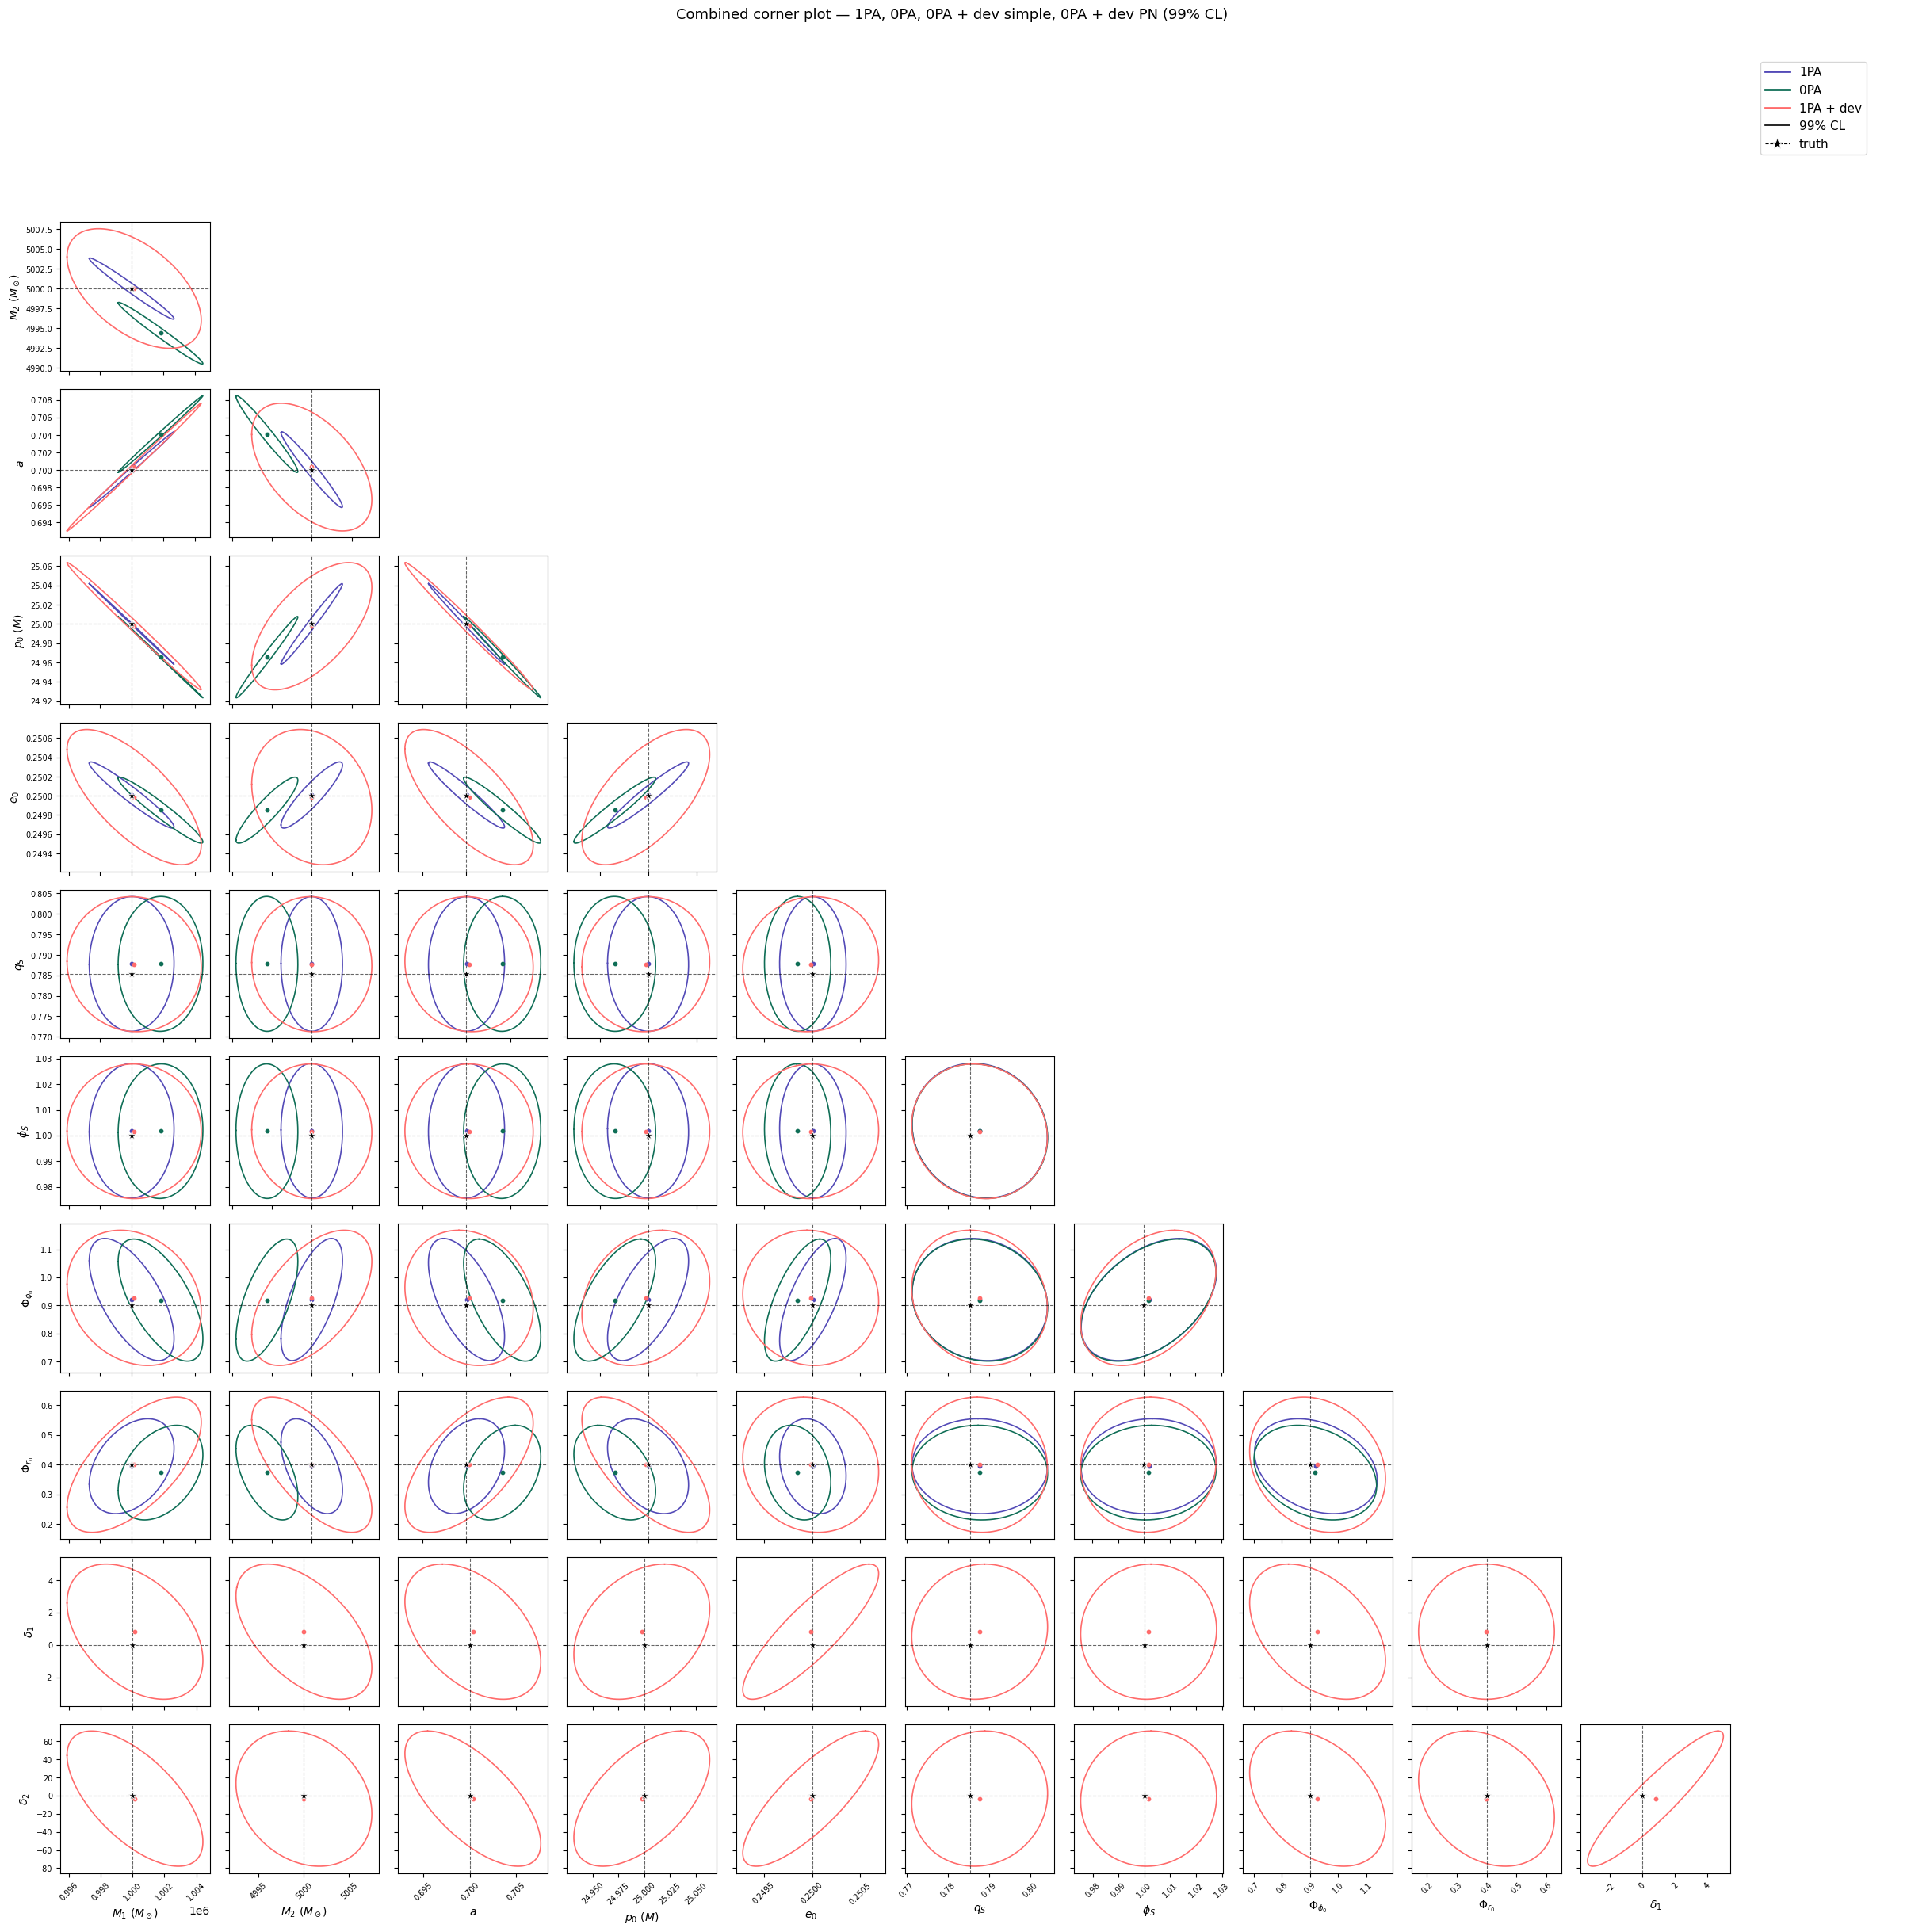

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434])
bf_0PA = np.array([1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]) 
bf_1_PA_dev= np.array([1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847])
# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('1PA + dev',          bf_1_PA_dev,       Covariance_1PA_dev,          '#FF6B6B', 11),

]
level= 0.99
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 


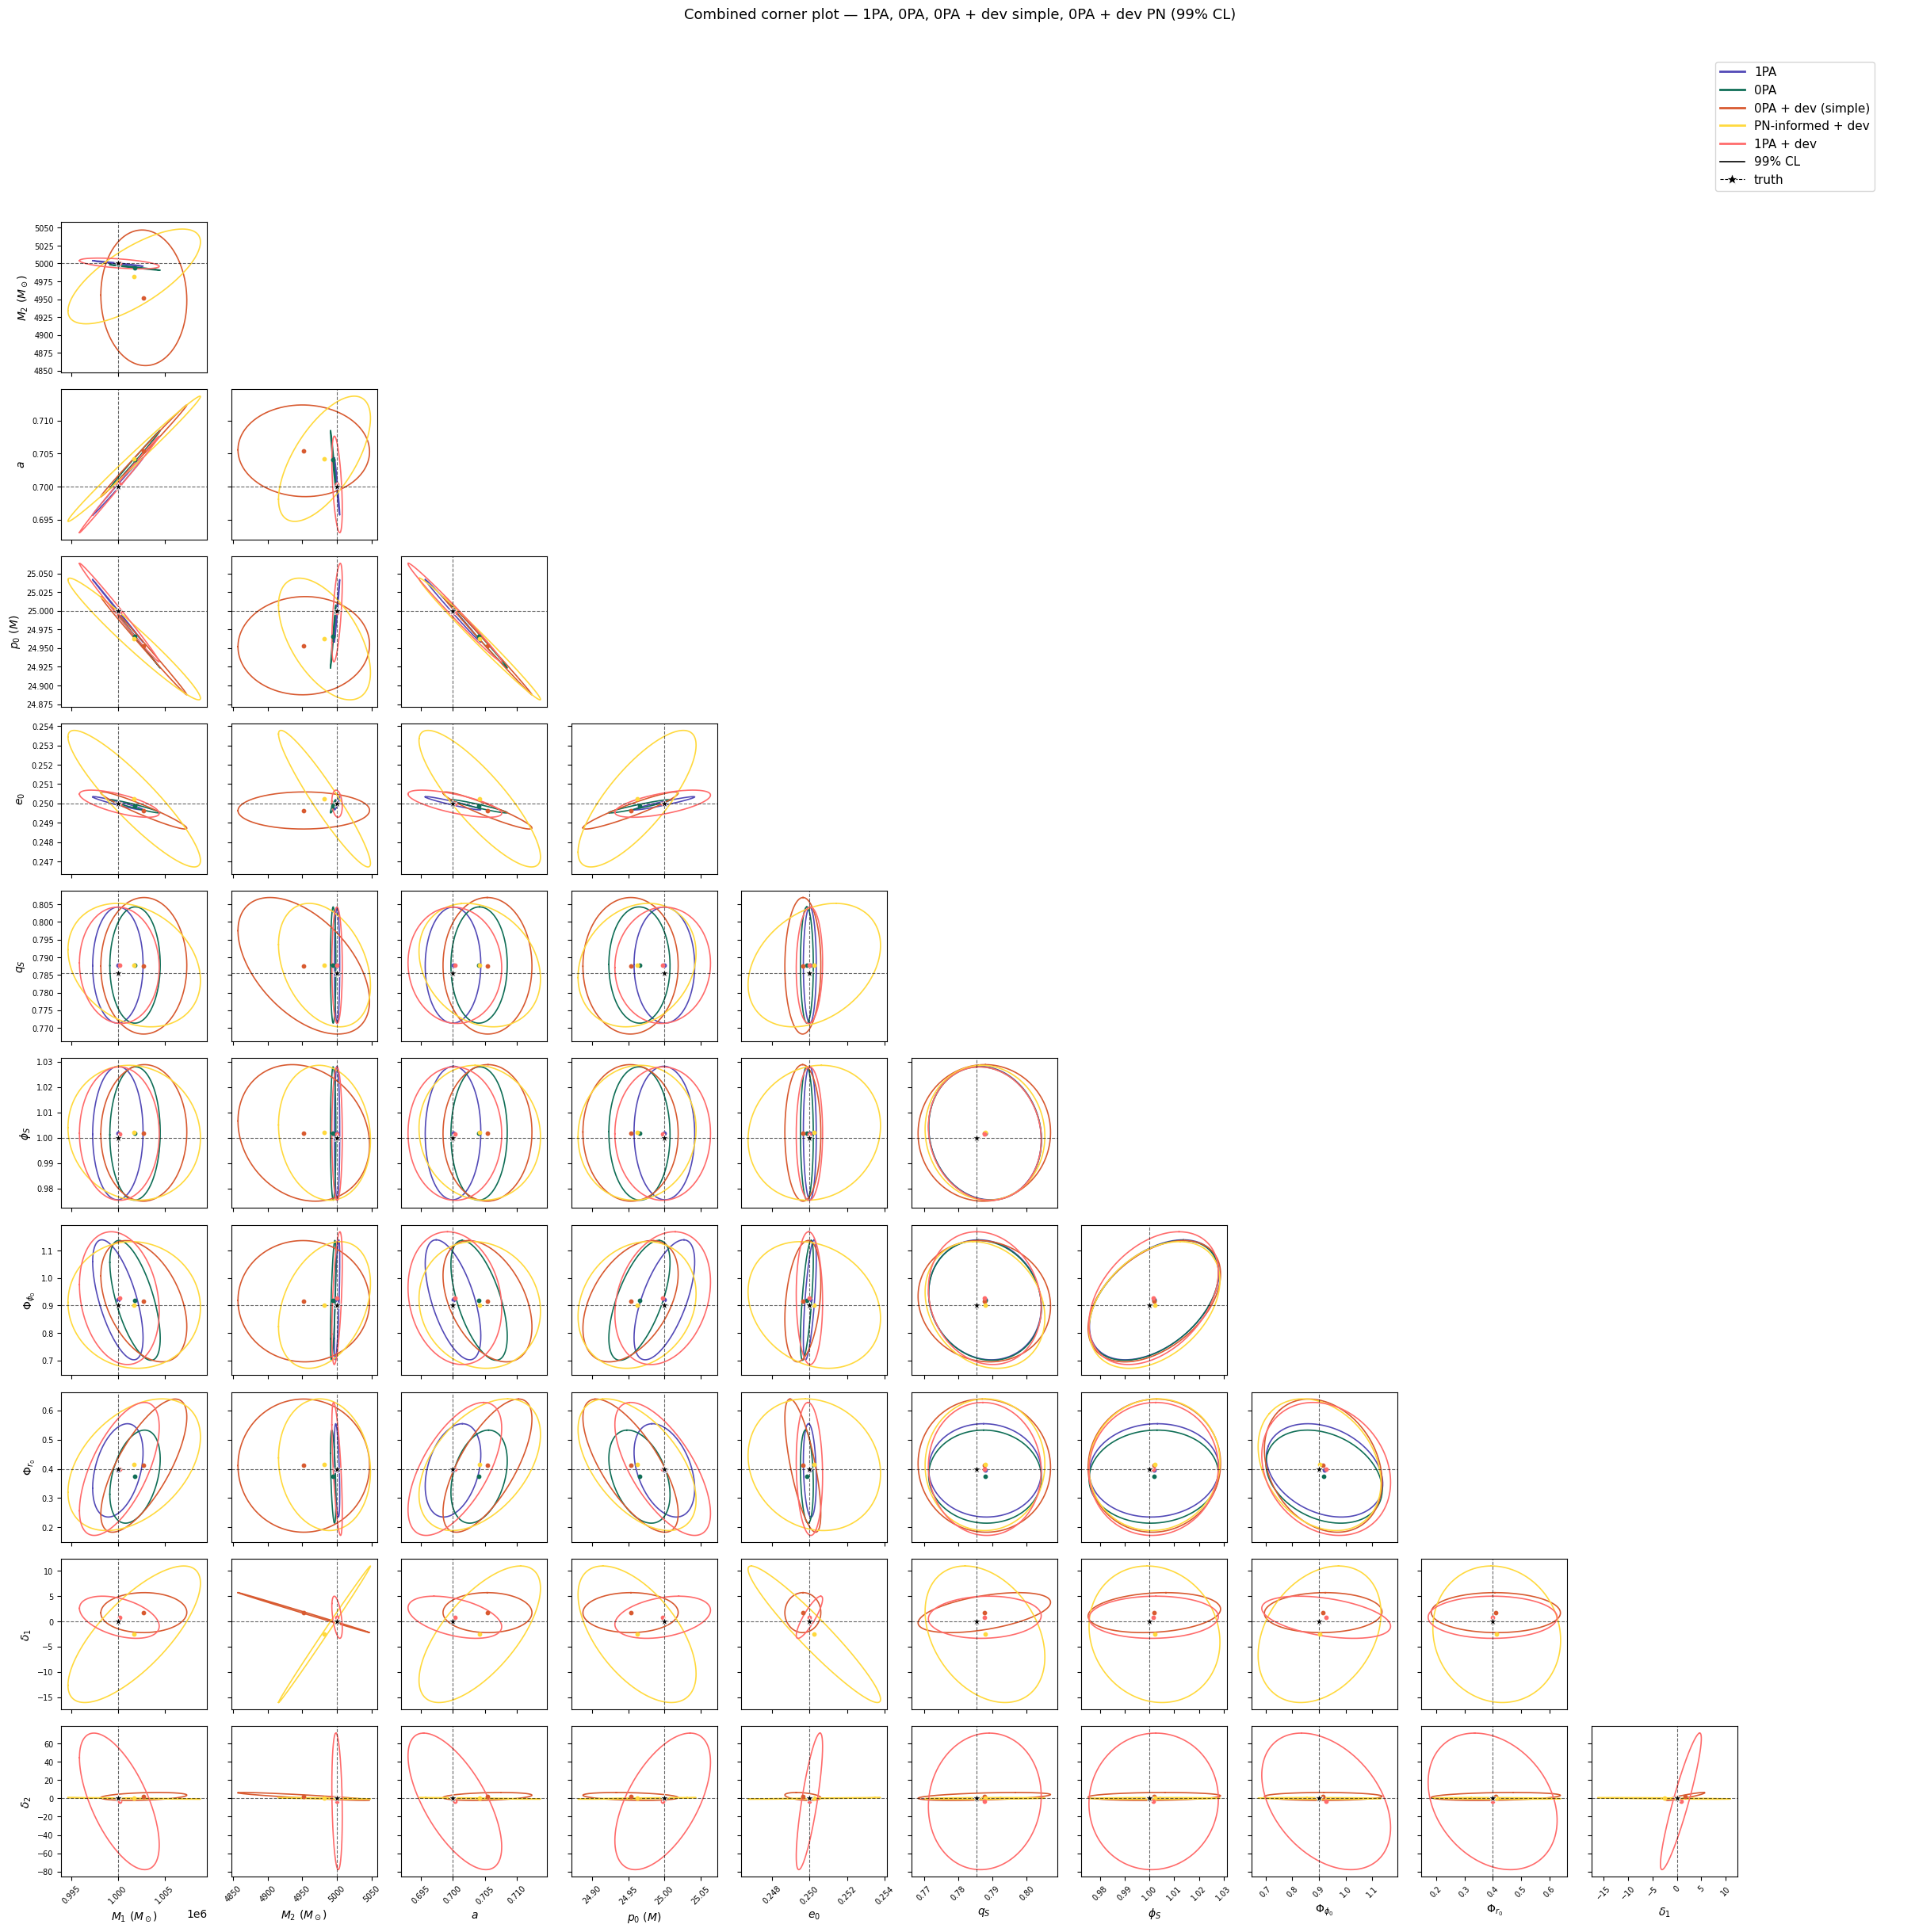

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# ── Best-fit values ───────────────────────────────────────────────────────────
bf_1PA = np.array([1000000.6157287196, 4999.999391375213, 0.7000474012600719, 24.99994304374421, 0.2500081838875367, 0.7877861127640066, 1.001873110230141, 0.9207595116762446, 0.39466840656966434])
bf_0PA = np.array([1001834.0613212539, 4994.388957707725, 0.7041074018353285, 24.965551023569503, 0.24985063640259927, 0.787803802721781, 1.0016857226809583, 0.9188081502959158, 0.3732041593117018]) 
bf_simple_dev = np.array([1002773.5087947377, 4951.996076834916, 0.7054139072521527, 24.953294077033906, 0.24963513535683254, 0.7875895689149237, 1.001918539952816, 0.9156601963955119, 0.4109580708321073, 1.7364060670631016, 2.1384810088591153])  
bf_PN_informed_dev = np.array([1001746.8662793704, 4981.874856346291, 0.7042095448190115, 24.96226811525148, 0.2502467124648788, 0.7877840055125346, 1.0019808615795052, 0.9019863610862191, 0.41409936930468483, -2.5508432126243203, -0.0019346983684825976])
bf_1_PA_dev= np.array([1000158.1195196154, 5000.006457832012, 0.7003353612309287, 24.99762788901373, 0.2499862333250135, 0.787731667415743, 1.0016393337689735, 0.926835171660422, 0.399606527220177, 0.8173148733981785, -3.275050808083847])

# True injected parameters — order MUST match `labels` below.
signal_param = {
    "m1": 1e6,
    "m2": 5.00000000e+03,
    "a": 0.70,
    "p0": 25.0,
    "e0": 0.25,
    "xI0": 1.0,
    "dist": 3,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.0000e-01,
}

true_params = np.array([
    signal_param["m1"], signal_param["m2"], signal_param["a"],
    signal_param["p0"], signal_param["e0"],
    signal_param["qS"], signal_param["phiS"],
    signal_param["Phi_phi0"], signal_param["Phi_r0"],
    0.0, 0.0,            # dev_1, dev_2 — true injection (0 if no deviation)
])

labels = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
          r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$',
          r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
          r'$\delta_1$', r'$\delta_2$']

# ── Per-fit configuration ─────────────────────────────────────────────────────
# (name, mean, covariance, color, n_params)
fits = [
    ('1PA',                bf_1PA,            Covariance_fit_1PA,            '#534AB7', 9),
    ('0PA',                bf_0PA,            Covariance_fit_0PA,            '#0F6E56', 9),
    ('0PA + dev (simple)', bf_simple_dev,     Covariance_fit_0PA_dev_simple, '#D85A30', 11),
    ('PN-informed + dev',  bf_PN_informed_dev, Covariance_fit_0PA_dev_PN_informed, '#FFD93D', 11),
    ('1PA + dev',          bf_1_PA_dev,       Covariance_1PA_dev,          '#FF6B6B', 11),

]
level= 0.99
LEVELS       = (level,)
LEVEL_STYLES = {level: '-'}
N_PARAMS     = 11
TRUTH_COLOR  = '#000000'
 
# ── Confidence-ellipse helper ─────────────────────────────────────────────────
def draw_ellipses(ax, mean, cov, i, j, color, levels, styles):
    cov2  = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
 
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order   = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]
 
    # Guard against negative eigenvalues from numerical noise
    eigvals = np.maximum(eigvals, 0)
 
    theta = np.linspace(0, 2 * np.pi, 400)
    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        ellipse = np.vstack([r1 * np.cos(theta), r2 * np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]
        ax.plot(ellipse[0], ellipse[1], color=color, lw=1.2, ls=styles[p])
 
# ── Combined corner plot ──────────────────────────────────────────────────────
def combined_triangle_plot():
    D = N_PARAMS
    fig, axes = plt.subplots(D, D, figsize=(2.2 * D, 2.2 * D))
 
    for i in range(D):
        for j in range(D):
            ax = axes[i, j]
 
            if j >= i:           # upper triangle + diagonal: hide
                ax.axis('off')
                continue
 
            for name, mean, cov, color, n in fits:
                if i >= n or j >= n:   # skip params this fit doesn't have
                    continue
                draw_ellipses(ax, mean, cov, j, i, color, LEVELS, LEVEL_STYLES)
                ax.scatter(mean[j], mean[i], color=color, s=10, zorder=3)
 
            # Truth lines & marker
            ax.axvline(true_params[j], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.axhline(true_params[i], color=TRUTH_COLOR, lw=0.8, ls='--', alpha=0.6)
            ax.scatter(true_params[j], true_params[i],
                       color=TRUTH_COLOR, marker='*', s=60, zorder=5,
                       edgecolor='white', linewidth=0.6)
 
            if i == D - 1:
                ax.set_xlabel(labels[j], fontsize=10)
                ax.tick_params(axis='x', labelrotation=45)
            else:
                ax.set_xticklabels([])
            if j == 0:
                ax.set_ylabel(labels[i], fontsize=10)
            else:
                ax.set_yticklabels([])
 
            ax.tick_params(labelsize=7)
 
    # Legend
    legend_handles = [plt.Line2D([0], [0], color=c, lw=2, label=name)
                      for name, _, _, c, _ in fits]
    legend_handles.append(plt.Line2D([0], [0], color='black', lw=1.2, ls='-',
                                     label='{:.0f}% CL'.format(level * 100)))
    legend_handles.append(plt.Line2D([0], [0], color=TRUTH_COLOR, marker='*',
                                     ls='--', lw=0.8, markersize=10,
                                     markeredgecolor='white', markeredgewidth=0.6,
                                     label='truth'))
 
    fig.legend(handles=legend_handles, loc='upper right',
               bbox_to_anchor=(0.98, 0.98), fontsize=11, frameon=True)
 
    fig.suptitle('Combined corner plot — 1PA, 0PA, 0PA + dev simple, 0PA + dev PN ({:.0f}% CL)'.format(level * 100),
                 fontsize=13, y=1.005)
    plt.tight_layout()
    # plt.savefig('corner_plot_99CL.pdf', bbox_inches='tight')
    plt.show()
 
combined_triangle_plot()
 
